/tmp/ipykernel_4137376/212003334.py:114: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g["pct"] * g["w"]).sum() / 100)
/tmp/ipykernel_4137376/212003334.py:114: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g["pct"] * g["w"]).sum() / 100)
/tmp/ipykernel_4137376/212003334.py:114: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is d

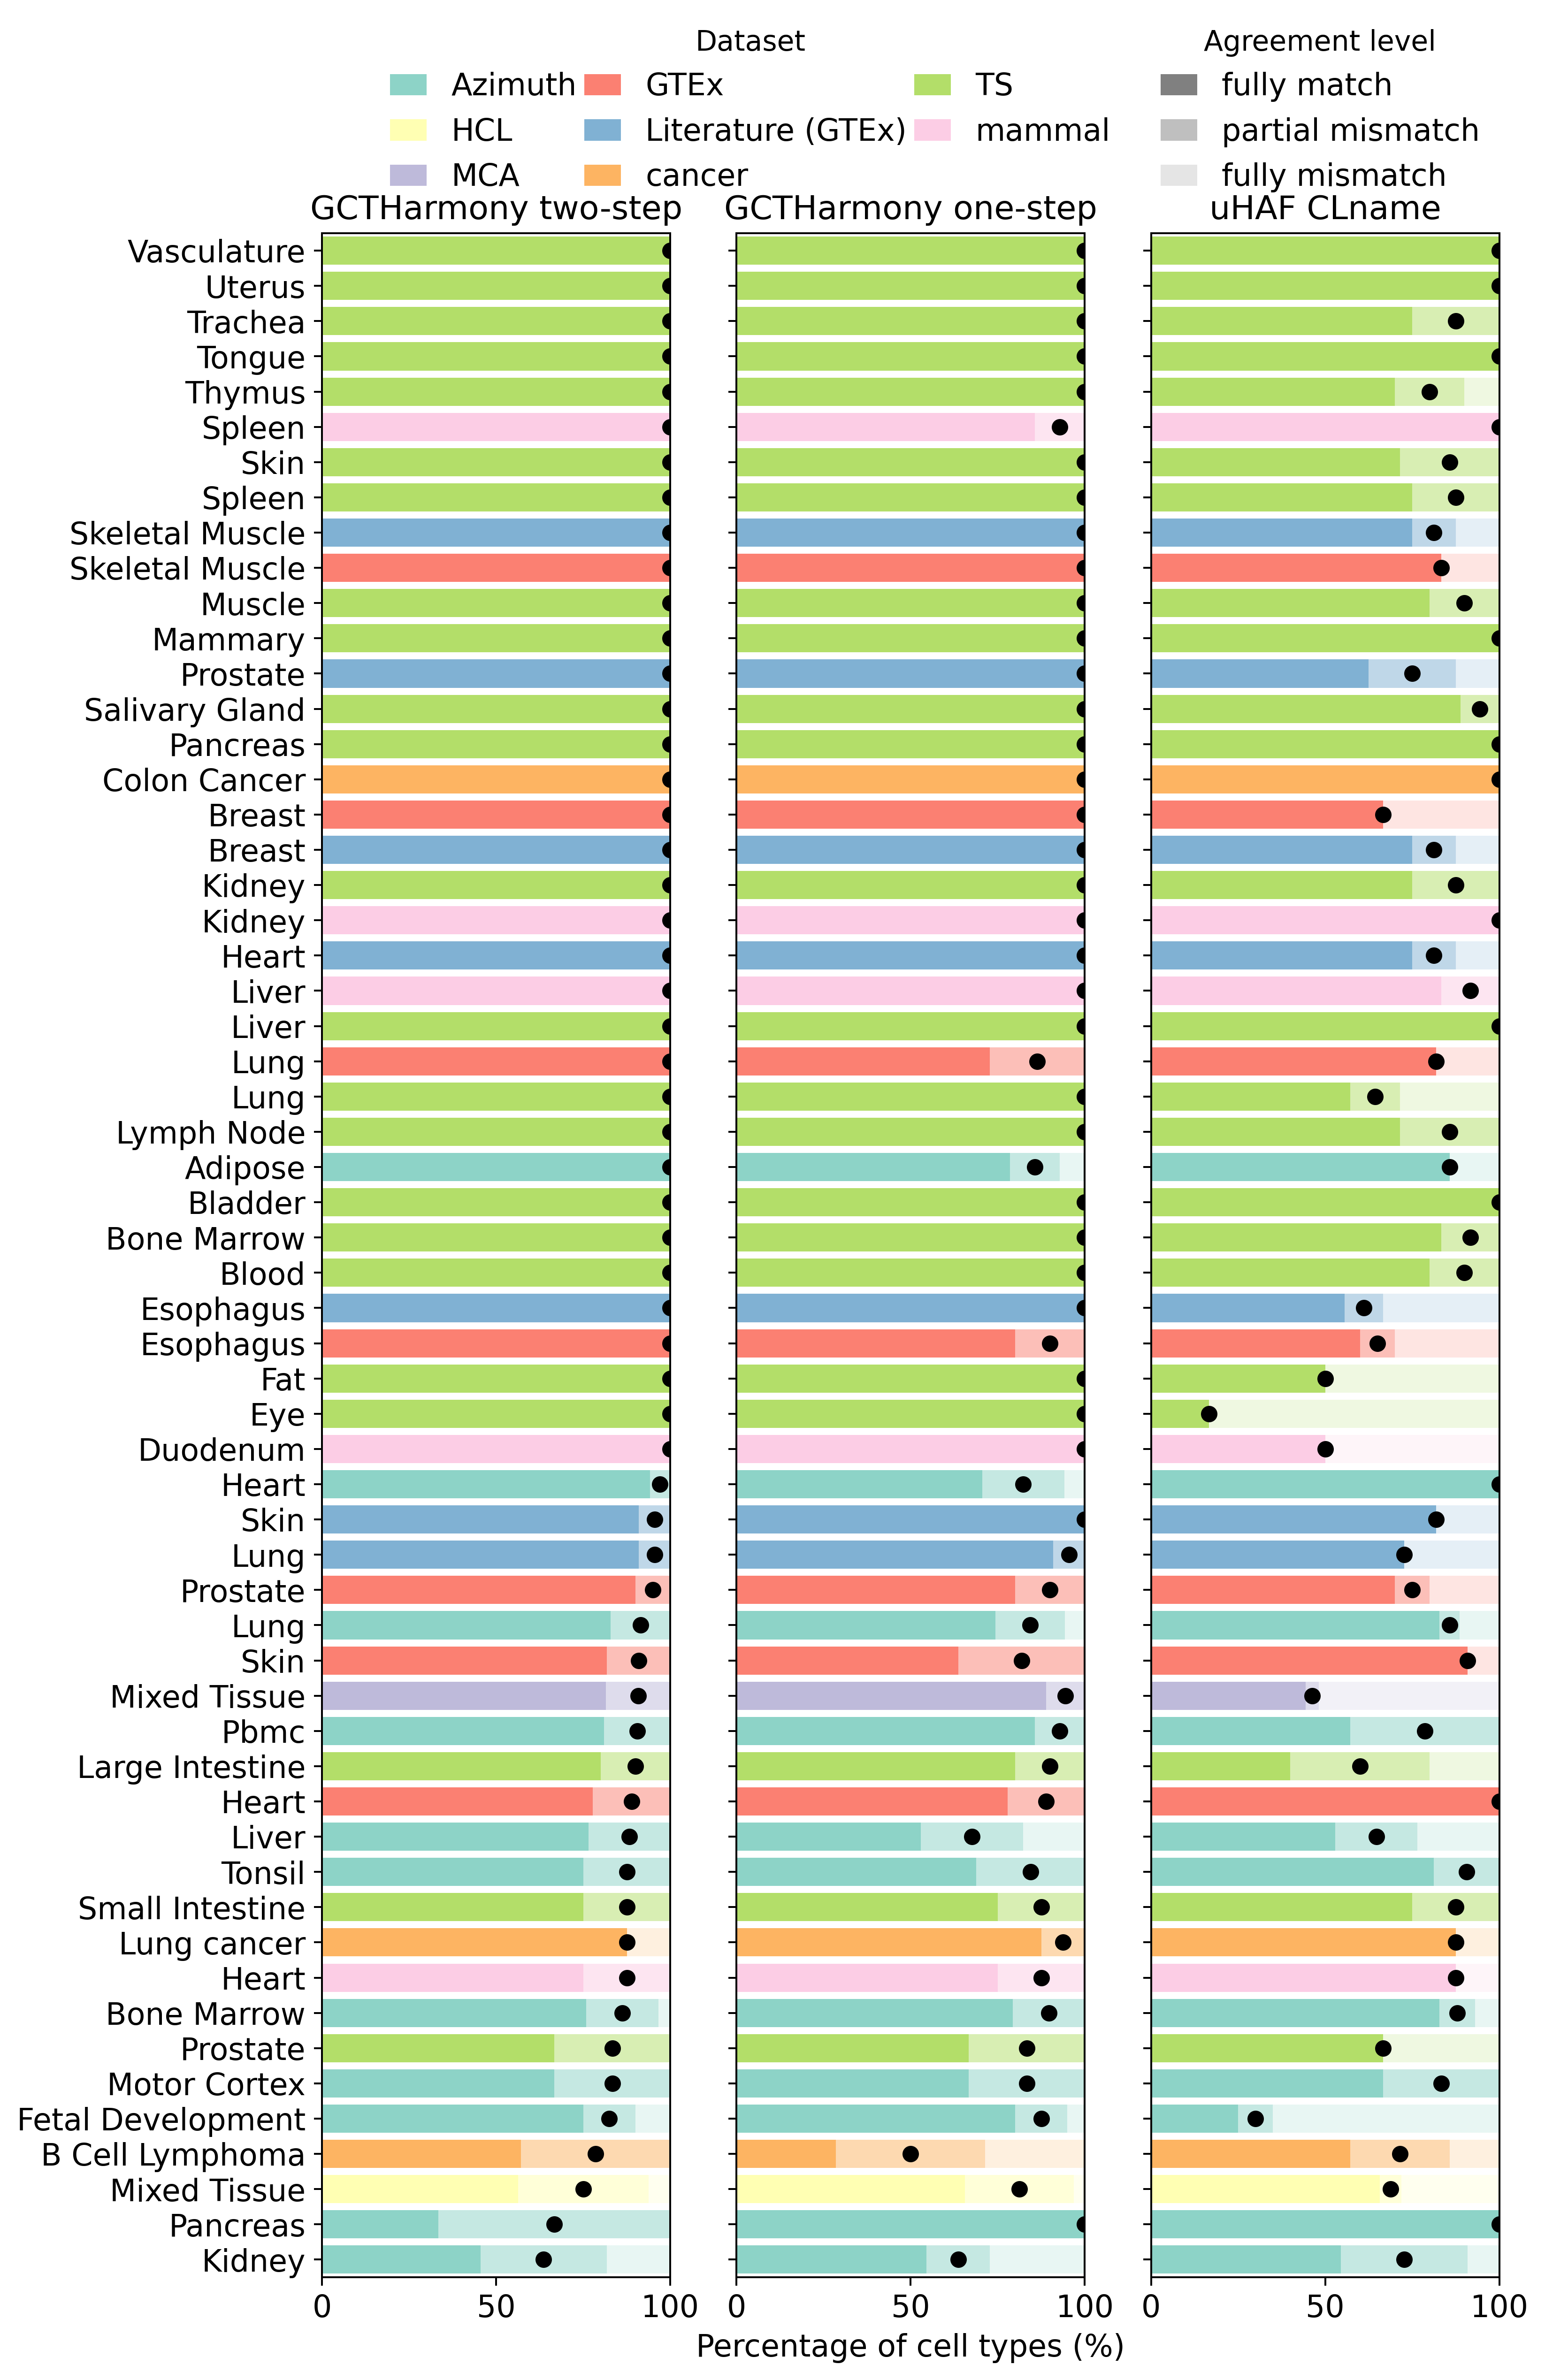

In [1]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

# ---------------------------------------------------------------------
# Load
# ---------------------------------------------------------------------
merged_tab = pd.read_excel("benchmarking_labeled.xlsx").copy()

# ---------------------------------------------------------------------
# Matplotlib style (same as yours)
# ---------------------------------------------------------------------
mpl.rcParams.update({
    "font.size"            : 20,
    "axes.titlesize"       : 14,
    "axes.labelsize"       : 13,
    "xtick.labelsize"      : 13,
    "ytick.labelsize"      : 13,
    "legend.fontsize"      : 13,
    "legend.title_fontsize": 12
})

alpha_map = {"fully match": 1.0, "partial mismatch": 0.50, "fully mismatch": 0.20}
score_map = {"fully match": 1.0, "partial mismatch": 0.50, "fully mismatch": 0.0}

# ---------------------------------------------------------------------
# Special case HCL/MCA
# ---------------------------------------------------------------------
mask_hcl_mca = merged_tab["dataset"].isin(["HCL", "MCA"])
merged_tab.loc[mask_hcl_mca, "tissue"] = "mixed tissue"

# ---------------------------------------------------------------------
# Normalize dataset names
# ---------------------------------------------------------------------
def normalize_dataset(ds):
    if pd.isna(ds):
        return ds
    ds = str(ds).strip()
    if ds == "literature":
        return "Literature (GTEx)"
    if ds in ["BCL", "coloncancer", "lungcancer"]:
        return "cancer"
    return ds

# ---------------------------------------------------------------------
# Normalize tissue names
#   1) lung cancer and brain metastasis -> Lung cancer
#   2) Capitalize all tissues (Title Case)
# ---------------------------------------------------------------------
def normalize_tissue(ts):
    if pd.isna(ts):
        return ts
    ts = str(ts).strip()
    if ts.lower() == "lung cancer and brain metastasis":
        return "Lung cancer"
    return ts.title()

merged_tab["dataset_norm"] = merged_tab["dataset"].map(normalize_dataset)
merged_tab["tissue"] = merged_tab["tissue"].map(normalize_tissue)

# ---------------------------------------------------------------------
# IMPORTANT: fix a bug from your original snippet
# You accidentally did: merged_tab['tissue'] = merged_tab['tissue'].map(normalize_dataset)
# That overwrote tissue with dataset-normalization.
# We DO NOT do that here.
# ---------------------------------------------------------------------

# ---------------------------------------------------------------------
# Ensure agreement labels use EXACT same vocabulary as your plotting maps
# Convert "partially match" -> "partial mismatch" if present
# ---------------------------------------------------------------------
agreement_cols = [
    "label for two-step with title and abstract",
    "label for one-step with title and abstract",
    "label for uhaf CLname",
]
for c in agreement_cols:
    if c in merged_tab.columns:
        merged_tab[c] = merged_tab[c].replace({"partially match": "partial mismatch"})

# ---------------------------------------------------------------------
# Colors by normalized dataset
# ---------------------------------------------------------------------
dataset_list = list(pd.unique(merged_tab["dataset_norm"]))
cmap = plt.get_cmap("Set3")
colors = [cmap(i) for i in range(cmap.N) if i != 8]  # skip grey-ish
dataset_colors = {ds: colors[i % len(colors)] for i, ds in enumerate(dataset_list)}

# ---------------------------------------------------------------------
# Pivot/score helper
# ---------------------------------------------------------------------
def make_pivot(df, agreement_col):
    df = df.copy()
    df["tissue_ds"] = df["tissue"].astype(str) + " | " + df["dataset_norm"].astype(str)

    tmp = (
        df.groupby(["tissue_ds", agreement_col])
          .size()
          .reset_index(name="n")
          .rename(columns={agreement_col: "agreement"})
    )
    tmp["pct"] = tmp["n"] / tmp.groupby("tissue_ds")["n"].transform("sum") * 100

    pivot = (
        tmp.pivot(index="tissue_ds", columns="agreement", values="pct")
           .fillna(0)
    )

    score = (
        tmp.assign(w=tmp["agreement"].map(score_map))
           .groupby("tissue_ds")
           .apply(lambda g: (g["pct"] * g["w"]).sum() / 100)
    )

    dataset_per_row = df.groupby("tissue_ds")["dataset_norm"].first()
    tissue_label_per_row = df.groupby("tissue_ds")["tissue"].first()

    return pivot, score, dataset_per_row, tissue_label_per_row

# ---------------------------------------------------------------------
# Build pivots: GPT (title+abstract) + uHAF CLname
# ---------------------------------------------------------------------
tw_pivot, tw_score, row_ds, row_tissue = make_pivot(
    merged_tab, "label for complex strategy"
)
on_pivot, on_score, _, _ = make_pivot(
    merged_tab, "label for simple strategy"
)
uh_pivot, uh_score, _, _ = make_pivot(
    merged_tab, "label for uhaf CLname"
)

# Sort rows by two-step score (ascending), like your reference
sorted_rows = tw_score.sort_values(ascending=True).index
tw_pivot   = tw_pivot.loc[sorted_rows]
on_pivot   = on_pivot.loc[sorted_rows]
uh_pivot   = uh_pivot.loc[sorted_rows]
tw_score   = tw_score.loc[sorted_rows]
on_score   = on_score.loc[sorted_rows]
uh_score   = uh_score.loc[sorted_rows]
row_ds     = row_ds.loc[sorted_rows]
row_tissue = row_tissue.loc[sorted_rows]

# ---------------------------------------------------------------------
# Plot (3 columns) — FIXED tissue labels with sharey=True
# ---------------------------------------------------------------------
fig, axes = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(12, 14), dpi=360)

def stacked_alpha_barh(ax, pivot, scores, row_ds_map, row_tissue_map, set_labels=False):
    agreements = ["fully match", "partial mismatch", "fully mismatch"]
    y_pos      = np.arange(len(pivot))
    cum_left   = np.zeros(len(pivot))

    for ag in agreements:
        widths = pivot[ag].values if ag in pivot.columns else np.zeros(len(pivot))
        for i, (w, row_key) in enumerate(zip(widths, pivot.index)):
            if w == 0:
                continue
            ds     = row_ds_map[row_key]
            base_c = dataset_colors[ds]
            color  = list(base_c)
            color[3] = alpha_map[ag]
            ax.barh(i, w, left=cum_left[i], height=0.8, color=color, edgecolor="none")
        cum_left += widths

    ax.scatter(scores * 100, y_pos, marker="o", color="black", zorder=5)

    # With sharey=True: set yticklabels ONLY ON ONE AXIS.
    ax.set_yticks(y_pos)
    if set_labels:
        ax.set_yticklabels([row_tissue_map[k] for k in pivot.index])
        ax.tick_params(axis="y", labelleft=True)
    else:
        ax.tick_params(axis="y", labelleft=False)

    ax.set_xlim(0, 100)
    ax.set_ylim(len(pivot) - 0.5, -0.5)
    ax.invert_yaxis()
    ax.set_xlabel("Percentage of cells (%)")

stacked_alpha_barh(axes[0], tw_pivot, tw_score, row_ds, row_tissue, set_labels=True)
axes[0].set_title("GCTHarmony two-step")

stacked_alpha_barh(axes[1], on_pivot, on_score, row_ds, row_tissue, set_labels=False)
axes[1].set_title("GCTHarmony one-step")

stacked_alpha_barh(axes[2], uh_pivot, uh_score, row_ds, row_tissue, set_labels=False)
axes[2].set_title("uHAF CLname")

axes[0].set_xlabel("")
axes[2].set_xlabel("")
axes[1].set_xlabel("Percentage of cell types (%)")

# Legends
ds_handles = [Patch(facecolor=dataset_colors[ds], label=ds) for ds in dataset_list]
fig.legend(
    handles=ds_handles, title="Dataset", loc="upper left",
    bbox_to_anchor=(0.4, 1.02), ncol=3, frameon=False,
    handlelength=1.2, columnspacing=0.25
)

grey = (0.5, 0.5, 0.5)
ag_order = ["fully match", "partial mismatch", "fully mismatch"]
ag_handles = [Patch(facecolor=(*grey, alpha_map[ag]), label=ag) for ag in ag_order]
fig.legend(
    handles=ag_handles, title="Agreement level", loc="upper left",
    bbox_to_anchor=(0.78, 1.02), ncol=1, frameon=False,
    handlelength=1.2, columnspacing=0.25
)

# Layout: make room for tissue labels on the left + top legends
plt.tight_layout(rect=[0, 0, 1, 0.96])
fig.subplots_adjust(left=0.38)  # increase if labels still clipped (0.38–0.45)

plt.show()


In [2]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------------------
# Load
# ---------------------------------------------------------------------
merged_tab = pd.read_excel("benchmarking_labeled.xlsx").copy()

# ---------------------------------------------------------------------
# Matplotlib style (not required for reporting, kept for consistency)
# ---------------------------------------------------------------------
mpl.rcParams.update({
    'font.size'            : 20,
    'axes.titlesize'       : 14,
    'axes.labelsize'       : 13,
    'xtick.labelsize'      : 13,
    'ytick.labelsize'      : 13,
    'legend.fontsize'      : 13,
    'legend.title_fontsize': 12
})

# ---------------------------------------------------------------------
# Agreement -> score map (same scoring definition you used in the figure)
# ---------------------------------------------------------------------
score_map = {
    'fully match'      : 1.0,
    'partial mismatch' : 0.50,
    'fully mismatch'   : 0.0
}

# ---------------------------------------------------------------------
# Special case HCL/MCA
# ---------------------------------------------------------------------
mask_hcl_mca = merged_tab['dataset'].isin(['HCL', 'MCA'])
merged_tab.loc[mask_hcl_mca, 'tissue'] = 'mixed tissue'

# ---------------------------------------------------------------------
# Normalize dataset / tissue names (same as yours)
# ---------------------------------------------------------------------
def normalize_dataset(ds):
    if ds == 'literature':
        return 'Literature (GTEx)'
    if ds in ['BCL', 'coloncancer', 'lungcancer']:
        return 'cancer'
    return ds

def normalize_tissue(ts):
    if ts == 'lung cancer and brain metastasis':
        return 'lung cancer'
    return ts

merged_tab['dataset_norm'] = merged_tab['dataset'].map(normalize_dataset)
merged_tab['tissue'] = merged_tab['tissue'].map(normalize_tissue)

# ---------------------------------------------------------------------
# Pivot/score helper (same scoring definition as your plot)
# ---------------------------------------------------------------------
def make_pivot(df, agreement_col):
    df = df.copy()
    df['tissue_ds'] = df['tissue'] + ' | ' + df['dataset_norm']

    tmp = (
        df.groupby(['tissue_ds', agreement_col])
          .size()
          .reset_index(name='n')
          .rename(columns={agreement_col: 'agreement'})
    )
    tmp['pct'] = tmp['n'] / tmp.groupby('tissue_ds')['n'].transform('sum') * 100

    pivot = (
        tmp.pivot(index='tissue_ds', columns='agreement', values='pct')
           .fillna(0)
    )

    score = (
        tmp.assign(w=tmp['agreement'].map(score_map))
           .groupby('tissue_ds')
           .apply(lambda g: (g['pct'] * g['w']).sum() / 100)
    )

    dataset_per_row = df.groupby('tissue_ds')['dataset_norm'].first()
    tissue_label_per_row = df.groupby('tissue_ds')['tissue'].first()

    return pivot, score, dataset_per_row, tissue_label_per_row

# ---------------------------------------------------------------------
# Compute per (tissue, dataset_norm) agreement score Series
# ---------------------------------------------------------------------
def compute_scores(df, label_col):
    """
    Returns a pandas Series:
      index  : tissue | dataset_norm
      values : agreement score in [0, 1]
    """
    _, score, _, _ = make_pivot(df, label_col)
    return score

# ---------------------------------------------------------------------
# Methods to summarize (requested + title/abstract context variants)
# ---------------------------------------------------------------------
methods = {
    "GPT one-step"                 : "label for simple strategy",
    "GPT two-step"                 : "label for complex strategy",
    "Qwen one-step"                : "label for qwen_onestep",
    "Qwen two-step"                : "label for qwen_twostep",
    "uHAF"                         : "label for uhaf CLname",
    "GPT(context) one-step"              : "label for one-step with title and abstract",
    "GPT(context) two-step"              : "label for two-step with title and abstract",
}

# ---------------------------------------------------------------------
# Build summary: mean/median across tissue–dataset pairs
# ---------------------------------------------------------------------
scores_dict = {}
missing = [col for col in methods.values() if col not in merged_tab.columns]
if missing:
    raise KeyError(
        "Some requested label columns are missing from the spreadsheet:\n"
        + "\n".join([f"- {c}" for c in missing])
    )

for method_name, col in methods.items():
    scores_dict[method_name] = compute_scores(merged_tab, col)

summary = (
    pd.DataFrame({
        "mean_agreement"  : {k: v.mean()   for k, v in scores_dict.items()},
        "median_agreement": {k: v.median() for k, v in scores_dict.items()},
        "n_pairs"         : {k: int(v.shape[0]) for k, v in scores_dict.items()},
    })
    .sort_values("mean_agreement", ascending=False)
)

# ---------------------------------------------------------------------
# Print results
# ---------------------------------------------------------------------
print("\n=== Mean / Median agreement score across tissue–dataset pairs ===")
print(summary.round(4))

# Optional: LaTeX-ready
print("\n=== LaTeX table (rounded to 3 decimals) ===")
print(summary.round(3).to_latex())

# Optional: export
out_csv = "agreement_score_mean_median_by_method.csv"
summary.to_csv(out_csv, index=True)
print(f"\nSaved: {out_csv}")

# ---------------------------------------------------------------------
# (Optional) Also export per-pair scores (handy for debugging / plotting)
# ---------------------------------------------------------------------
per_pair = pd.DataFrame(scores_dict)
per_pair.index.name = "tissue | dataset_norm"
per_pair.to_csv("agreement_score_per_tissue_dataset_by_method.csv")
print("Saved: agreement_score_per_tissue_dataset_by_method.csv")


/tmp/ipykernel_4137376/2795690758.py:80: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g['pct'] * g['w']).sum() / 100)
/tmp/ipykernel_4137376/2795690758.py:80: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g['pct'] * g['w']).sum() / 100)
/tmp/ipykernel_4137376/2795690758.py:80: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is d


=== Mean / Median agreement score across tissue–dataset pairs ===
                       mean_agreement  median_agreement  n_pairs
GPT(context) two-step          0.9493            1.0000       58
GPT two-step                   0.9453            1.0000       58
GPT one-step                   0.9335            1.0000       58
Qwen one-step                  0.9119            1.0000       58
Qwen two-step                  0.8355            0.8750       58
uHAF                           0.8112            0.8571       58
GPT(context) one-step          0.7963            0.8469       58

=== LaTeX table (rounded to 3 decimals) ===
\begin{tabular}{lrrr}
\toprule
 & mean_agreement & median_agreement & n_pairs \\
\midrule
GPT(context) two-step & 0.949000 & 1.000000 & 58 \\
GPT two-step & 0.945000 & 1.000000 & 58 \\
GPT one-step & 0.934000 & 1.000000 & 58 \\
Qwen one-step & 0.912000 & 1.000000 & 58 \\
Qwen two-step & 0.836000 & 0.875000 & 58 \\
uHAF & 0.811000 & 0.857000 & 58 \\
GPT(context) one-

/tmp/ipykernel_4137376/3996788223.py:83: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g['pct'] * g['w']).sum() / 100)
/tmp/ipykernel_4137376/3996788223.py:83: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g['pct'] * g['w']).sum() / 100)


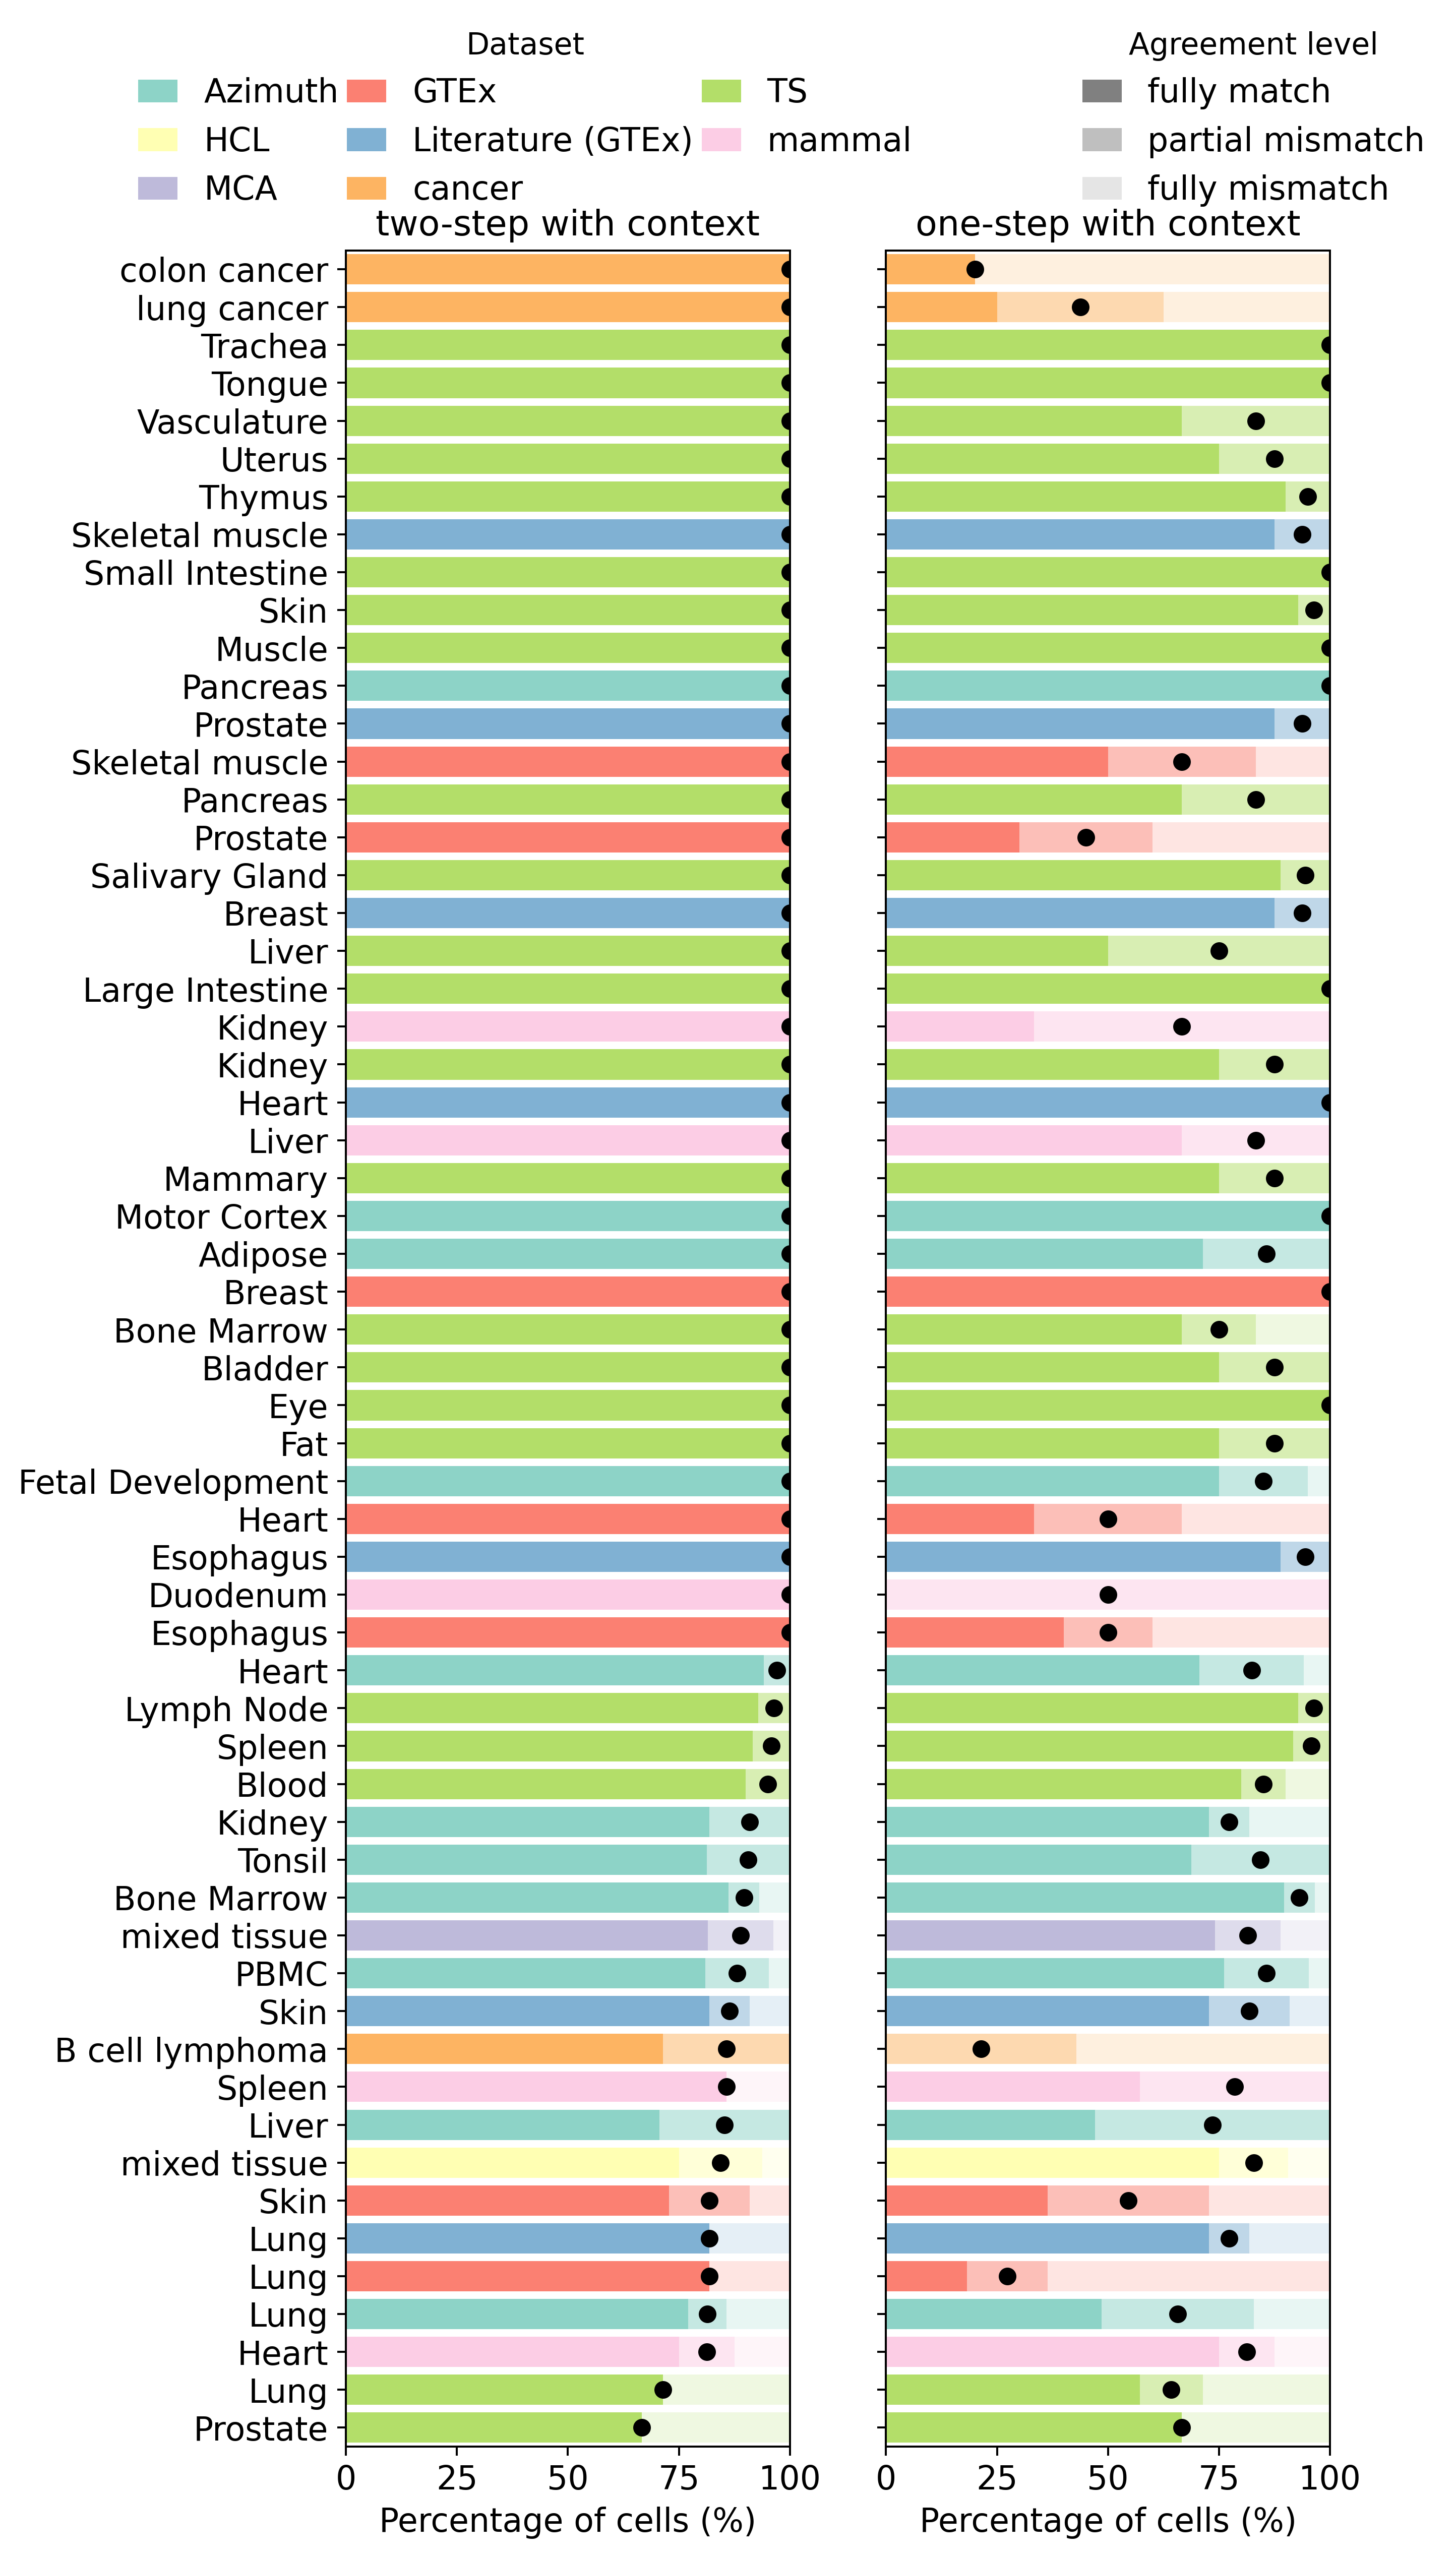

In [6]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

# ---------------------------------------------------------------------
# Load
# ---------------------------------------------------------------------
# merged_tab = pd.read_excel("Figure_2c_data_merged_all_methods_relabel_ontology_string.xlsx").copy()
merged_tab = pd.read_excel('benchmarking_labeled.xlsx')
# ---------------------------------------------------------------------
# Matplotlib style (same as yours)
# ---------------------------------------------------------------------
mpl.rcParams.update({
    'font.size'            : 20,
    'axes.titlesize'       : 14,
    'axes.labelsize'       : 13,
    'xtick.labelsize'      : 13,
    'ytick.labelsize'      : 13,
    'legend.fontsize'      : 13,
    'legend.title_fontsize': 12
})

alpha_map = {'fully match': 1.0, 'partial mismatch': 0.50, 'fully mismatch': 0.20}
score_map = {'fully match': 1.0, 'partial mismatch': 0.50, 'fully mismatch': 0.0}

# ---------------------------------------------------------------------
# Special case HCL/MCA
# ---------------------------------------------------------------------
mask_hcl_mca = merged_tab['dataset'].isin(['HCL', 'MCA'])
merged_tab.loc[mask_hcl_mca, 'tissue'] = 'mixed tissue'

# ---------------------------------------------------------------------
# Normalize dataset names
# ---------------------------------------------------------------------
def normalize_dataset(ds):
    if ds == 'literature':
        return 'Literature (GTEx)'
    if ds in ['BCL', 'coloncancer', 'lungcancer']:
        return 'cancer'
    return ds

def normalize_tissue(ts):
    if ts == 'lung cancer and brain metastasis':
        return 'lung cancer'
    return ts

merged_tab['dataset_norm'] = merged_tab['dataset'].map(normalize_dataset)
merged_tab['tissue'] = merged_tab['tissue'].map(normalize_tissue)

# ---------------------------------------------------------------------
# Colors by normalized dataset
# ---------------------------------------------------------------------
dataset_list = merged_tab['dataset_norm'].unique()
cmap = plt.get_cmap('Set3')
colors = [cmap(i) for i in range(cmap.N) if i != 8]  # skip grey-ish
dataset_colors = {ds: colors[i % len(colors)] for i, ds in enumerate(dataset_list)}

# ---------------------------------------------------------------------
# Pivot/score helper
# ---------------------------------------------------------------------
def make_pivot(df, agreement_col):
    df = df.copy()
    df['tissue_ds'] = df['tissue'] + ' | ' + df['dataset_norm']

    tmp = (
        df.groupby(['tissue_ds', agreement_col])
          .size()
          .reset_index(name='n')
          .rename(columns={agreement_col: 'agreement'})
    )
    tmp['pct'] = tmp['n'] / tmp.groupby('tissue_ds')['n'].transform('sum') * 100

    pivot = (
        tmp.pivot(index='tissue_ds', columns='agreement', values='pct')
           .fillna(0)
    )

    score = (
        tmp.assign(w=tmp['agreement'].map(score_map))
           .groupby('tissue_ds')
           .apply(lambda g: (g['pct'] * g['w']).sum() / 100)
    )

    dataset_per_row = df.groupby('tissue_ds')['dataset_norm'].first()
    tissue_label_per_row = df.groupby('tissue_ds')['tissue'].first()

    return pivot, score, dataset_per_row, tissue_label_per_row

# ---------------------------------------------------------------------
# Build pivots for GPT (title+abstract)
# ---------------------------------------------------------------------
tw_pivot, tw_score, row_ds, row_tissue = make_pivot(
    merged_tab, 'label for two-step with title and abstract'
)
on_pivot, on_score, _, _ = make_pivot(
    merged_tab, 'label for one-step with title and abstract'
)

# Sort rows by two-step score (ascending), like your reference
sorted_rows = tw_score.sort_values(ascending=True).index
tw_pivot  = tw_pivot.loc[sorted_rows]
on_pivot  = on_pivot.loc[sorted_rows]
tw_score  = tw_score.loc[sorted_rows]
on_score  = on_score.loc[sorted_rows]
row_ds    = row_ds.loc[sorted_rows]
row_tissue= row_tissue.loc[sorted_rows]

# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------
fig, axes = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(8, 14), dpi=360)

def stacked_alpha_barh(ax, pivot, scores, row_ds_map, row_tissue_map):
    agreements = ['fully match', 'partial mismatch', 'fully mismatch']
    y_pos      = np.arange(len(pivot))
    cum_left   = np.zeros(len(pivot))

    for ag in agreements:
        widths = pivot[ag].values if ag in pivot.columns else np.zeros(len(pivot))
        for i, (w, row_key) in enumerate(zip(widths, pivot.index)):
            if w == 0:
                continue
            ds      = row_ds_map[row_key]
            base_c  = dataset_colors[ds]
            color   = list(base_c)
            color[3]= alpha_map[ag]
            ax.barh(i, w, left=cum_left[i], height=0.8, color=color, edgecolor='none')
        cum_left += widths

    ax.scatter(scores * 100, y_pos, marker='o', color='black', zorder=5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([row_tissue_map[k] for k in pivot.index])
    ax.set_xlim(0, 100)
    ax.set_ylim(len(pivot) - 0.5, -0.5)
    ax.invert_yaxis()
    ax.set_xlabel('Percentage of cells (%)')

stacked_alpha_barh(axes[0], tw_pivot, tw_score, row_ds, row_tissue)
axes[0].set_title('two-step with context')

stacked_alpha_barh(axes[1], on_pivot, on_score, row_ds, row_tissue)
axes[1].set_title('one-step with context')
axes[1].set_ylabel('')

# Legends
ds_handles = [Patch(facecolor=dataset_colors[ds], label=ds) for ds in dataset_list]
fig.legend(handles=ds_handles, title='Dataset', loc='upper left',
           bbox_to_anchor=(0.1, 1.02), ncol=3, frameon=False,
           handlelength=1.2, columnspacing=0.25)

grey = (0.5, 0.5, 0.5)
ag_order = ['fully match', 'partial mismatch', 'fully mismatch']
ag_handles = [Patch(facecolor=(*grey, alpha_map[ag]), label=ag) for ag in ag_order]
fig.legend(handles=ag_handles, title='Agreement level', loc='upper left',
           bbox_to_anchor=(0.75, 1.02), ncol=1, frameon=False,
           handlelength=1.2, columnspacing=0.25)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


/tmp/ipykernel_762624/1211638525.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uhaf_tab['dataset_norm'] = uhaf_tab['dataset'].map(normalize_dataset)
/tmp/ipykernel_762624/1211638525.py:77: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g['pct'] * g['w']).sum() / 100)
/tmp/ipykernel_762624/1211638525.py:77: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version

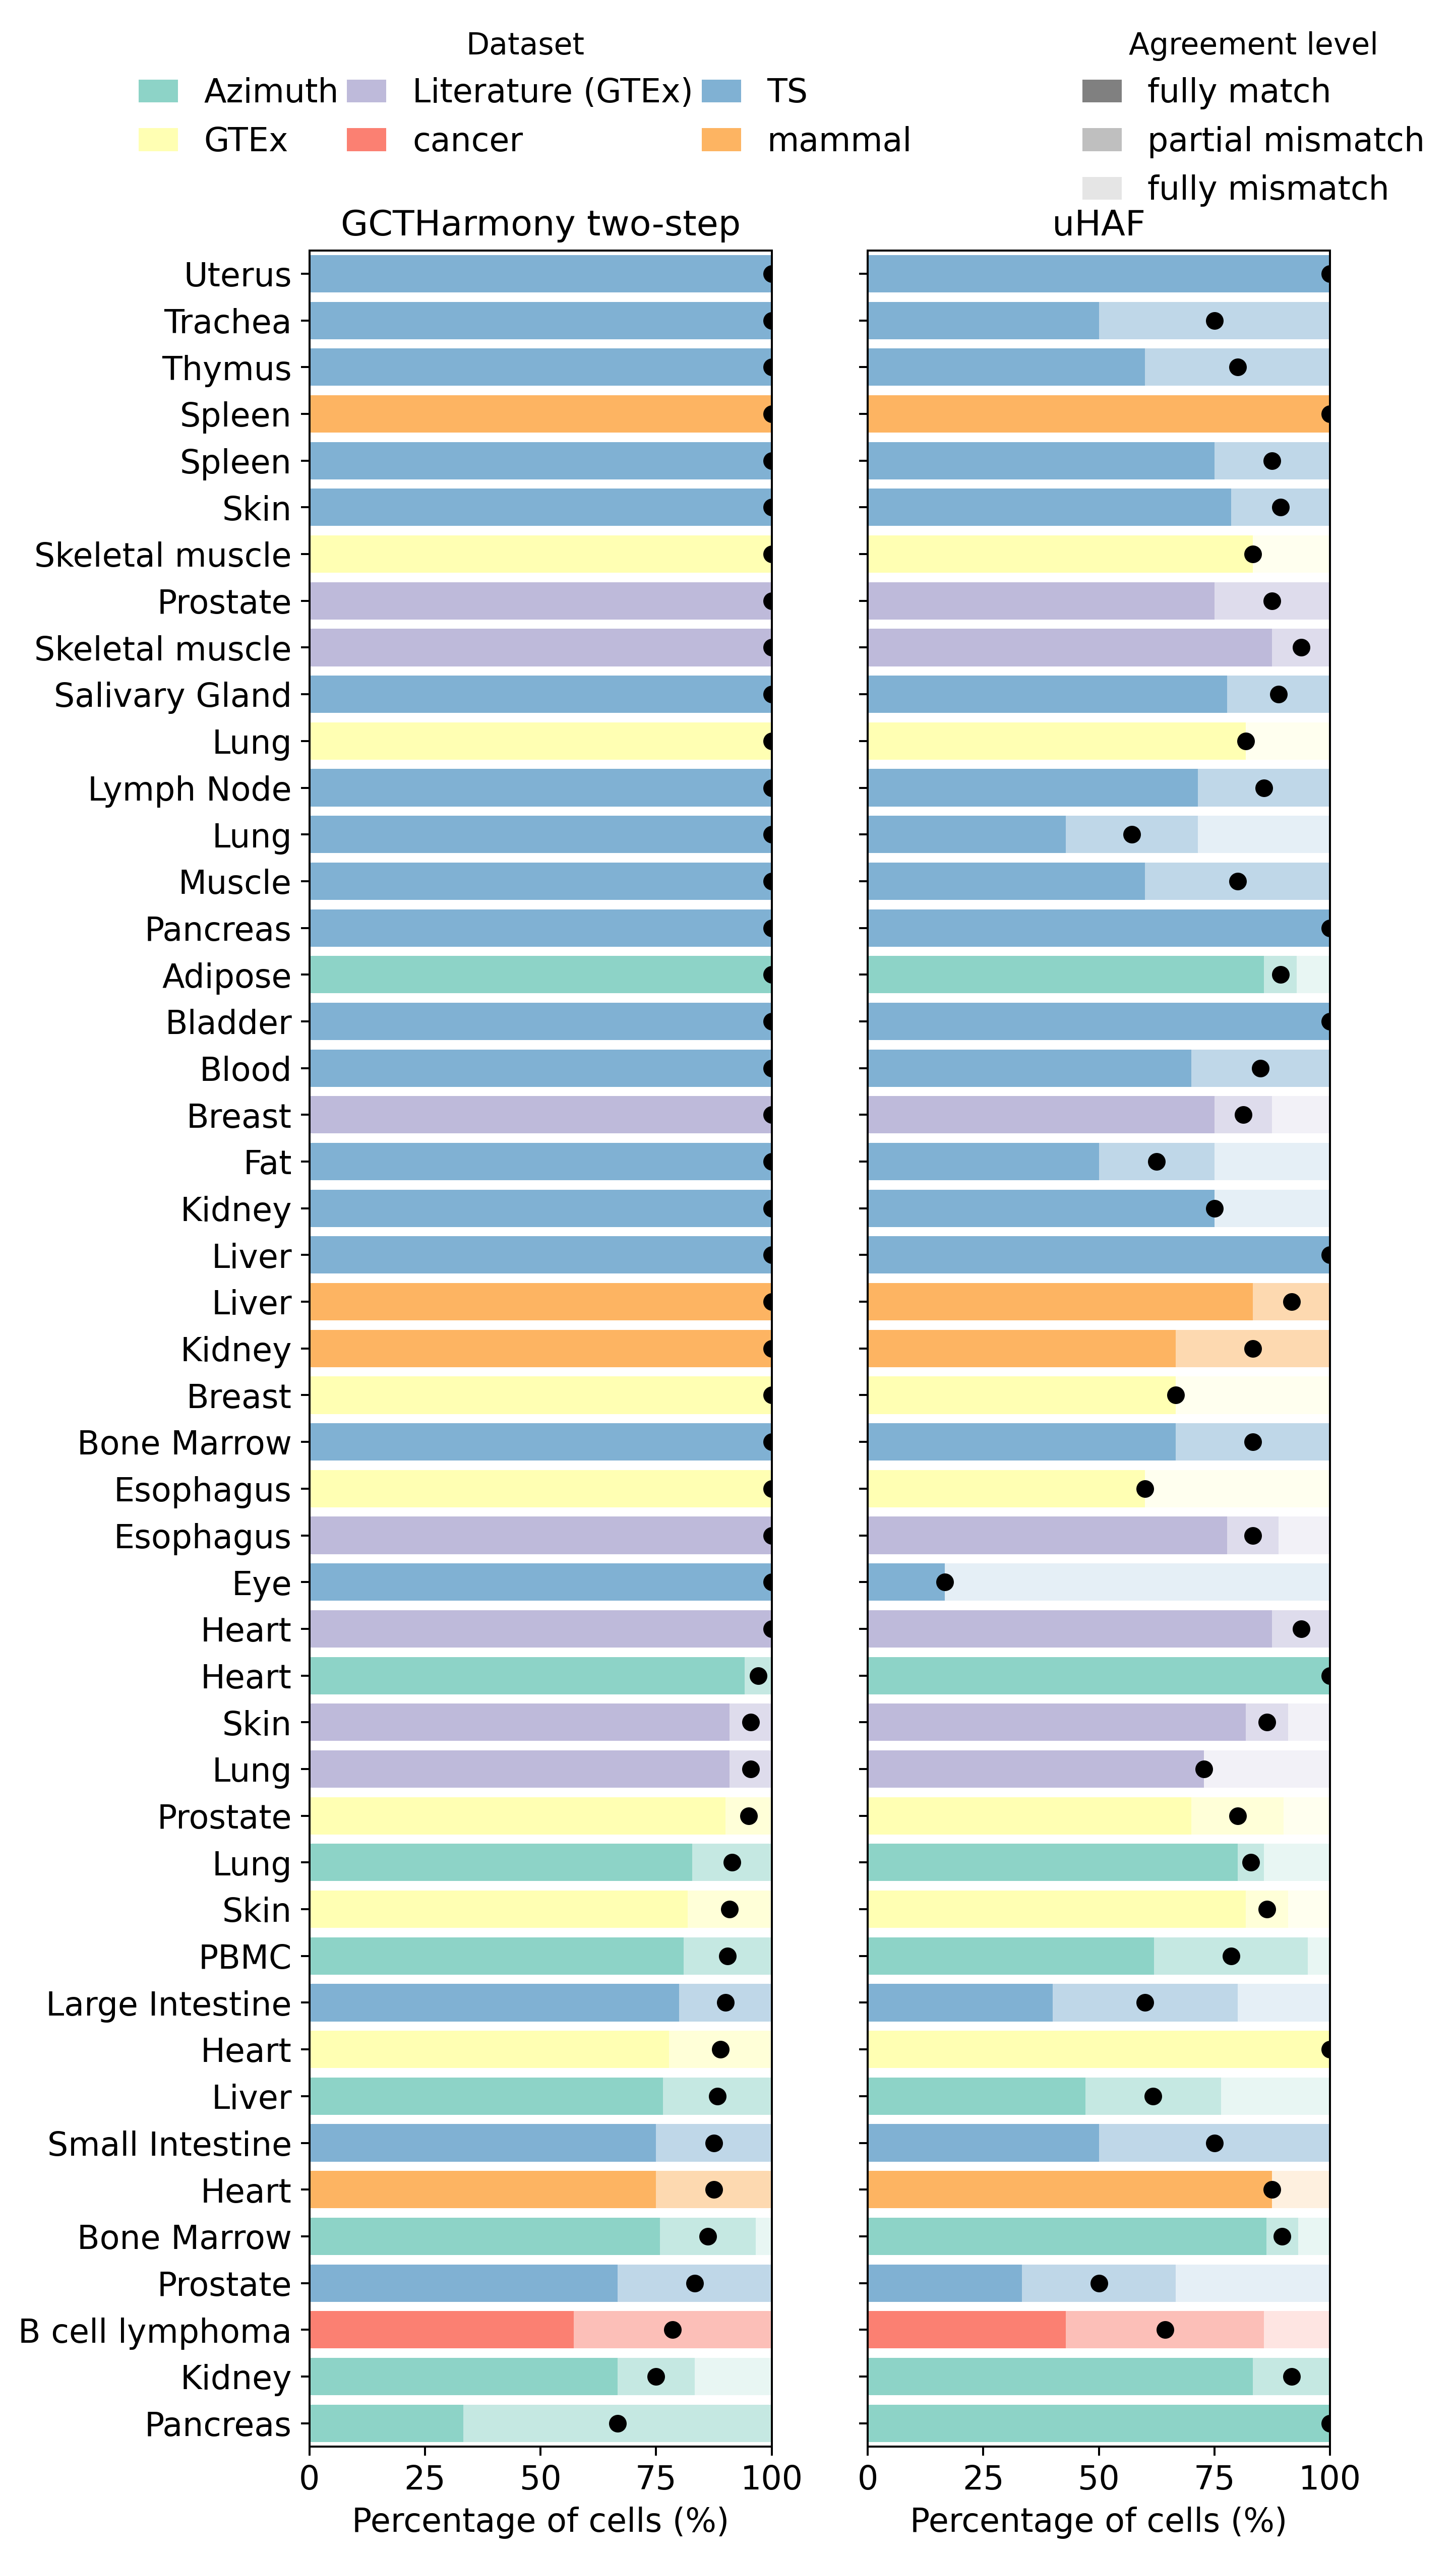

In [2]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

# ---------------------------------------------------------------------
# Load
# ---------------------------------------------------------------------
uhaf_tab = merged_tab.dropna(subset=['uhaf CLname'])

# ---------------------------------------------------------------------
# Matplotlib style (same as yours)
# ---------------------------------------------------------------------
mpl.rcParams.update({
    'font.size'            : 20,
    'axes.titlesize'       : 14,
    'axes.labelsize'       : 13,
    'xtick.labelsize'      : 13,
    'ytick.labelsize'      : 13,
    'legend.fontsize'      : 13,
    'legend.title_fontsize': 12
})

alpha_map = {'fully match': 1.0, 'partial mismatch': 0.50, 'fully mismatch': 0.20}
score_map = {'fully match': 1.0, 'partial mismatch': 0.50, 'fully mismatch': 0.0}

# ---------------------------------------------------------------------
# Special case HCL/MCA
# ---------------------------------------------------------------------
mask_hcl_mca = uhaf_tab['dataset'].isin(['HCL', 'MCA'])
uhaf_tab.loc[mask_hcl_mca, 'tissue'] = 'mixed tissue'

# ---------------------------------------------------------------------
# Normalize dataset names
# ---------------------------------------------------------------------
def normalize_dataset(ds):
    if ds == 'literature':
        return 'Literature (GTEx)'
    if ds in ['BCL', 'coloncancer', 'lungcancer']:
        return 'cancer'
    return ds

uhaf_tab['dataset_norm'] = uhaf_tab['dataset'].map(normalize_dataset)

# ---------------------------------------------------------------------
# Colors by normalized dataset
# ---------------------------------------------------------------------
dataset_list = uhaf_tab['dataset_norm'].unique()
cmap = plt.get_cmap('Set3')
colors = [cmap(i) for i in range(cmap.N) if i != 8]  # skip grey-ish
dataset_colors = {ds: colors[i % len(colors)] for i, ds in enumerate(dataset_list)}

# ---------------------------------------------------------------------
# Pivot/score helper
# ---------------------------------------------------------------------
def make_pivot(df, agreement_col):
    df = df.copy()
    df['tissue_ds'] = df['tissue'] + ' | ' + df['dataset_norm']

    tmp = (
        df.groupby(['tissue_ds', agreement_col])
          .size()
          .reset_index(name='n')
          .rename(columns={agreement_col: 'agreement'})
    )
    tmp['pct'] = tmp['n'] / tmp.groupby('tissue_ds')['n'].transform('sum') * 100

    pivot = (
        tmp.pivot(index='tissue_ds', columns='agreement', values='pct')
           .fillna(0)
    )

    score = (
        tmp.assign(w=tmp['agreement'].map(score_map))
           .groupby('tissue_ds')
           .apply(lambda g: (g['pct'] * g['w']).sum() / 100)
    )

    dataset_per_row = df.groupby('tissue_ds')['dataset_norm'].first()
    tissue_label_per_row = df.groupby('tissue_ds')['tissue'].first()

    return pivot, score, dataset_per_row, tissue_label_per_row

# ---------------------------------------------------------------------
# Build pivots for GPT (title+abstract)
# ---------------------------------------------------------------------
tw_pivot, tw_score, row_ds, row_tissue = make_pivot(
    uhaf_tab, 'label for complex strategy'
)
on_pivot, on_score, _, _ = make_pivot(
    uhaf_tab, 'label for uhaf CLname'
)

# Sort rows by two-step score (ascending), like your reference
sorted_rows = tw_score.sort_values(ascending=True).index
tw_pivot  = tw_pivot.loc[sorted_rows]
on_pivot  = on_pivot.loc[sorted_rows]
tw_score  = tw_score.loc[sorted_rows]
on_score  = on_score.loc[sorted_rows]
row_ds    = row_ds.loc[sorted_rows]
row_tissue= row_tissue.loc[sorted_rows]

# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------
fig, axes = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(8, 14), dpi=360)

def stacked_alpha_barh(ax, pivot, scores, row_ds_map, row_tissue_map):
    agreements = ['fully match', 'partial mismatch', 'fully mismatch']
    y_pos      = np.arange(len(pivot))
    cum_left   = np.zeros(len(pivot))

    for ag in agreements:
        widths = pivot[ag].values if ag in pivot.columns else np.zeros(len(pivot))
        for i, (w, row_key) in enumerate(zip(widths, pivot.index)):
            if w == 0:
                continue
            ds      = row_ds_map[row_key]
            base_c  = dataset_colors[ds]
            color   = list(base_c)
            color[3]= alpha_map[ag]
            ax.barh(i, w, left=cum_left[i], height=0.8, color=color, edgecolor='none')
        cum_left += widths

    ax.scatter(scores * 100, y_pos, marker='o', color='black', zorder=5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([row_tissue_map[k] for k in pivot.index])
    ax.set_xlim(0, 100)
    ax.set_ylim(len(pivot) - 0.5, -0.5)
    ax.invert_yaxis()
    ax.set_xlabel('Percentage of cells (%)')

stacked_alpha_barh(axes[0], tw_pivot, tw_score, row_ds, row_tissue)
axes[0].set_title('GCTHarmony two-step')

stacked_alpha_barh(axes[1], on_pivot, on_score, row_ds, row_tissue)
axes[1].set_title('uHAF')
axes[1].set_ylabel('')

# Legends
ds_handles = [Patch(facecolor=dataset_colors[ds], label=ds) for ds in dataset_list]
fig.legend(handles=ds_handles, title='Dataset', loc='upper left',
           bbox_to_anchor=(0.1, 1.02), ncol=3, frameon=False,
           handlelength=1.2, columnspacing=0.25)

grey = (0.5, 0.5, 0.5)
ag_order = ['fully match', 'partial mismatch', 'fully mismatch']
ag_handles = [Patch(facecolor=(*grey, alpha_map[ag]), label=ag) for ag in ag_order]
fig.legend(handles=ag_handles, title='Agreement level', loc='upper left',
           bbox_to_anchor=(0.75, 1.02), ncol=1, frameon=False,
           handlelength=1.2, columnspacing=0.25)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


Number of paired tissue|dataset points: 58
Wilcoxon signed-rank: statistic=213.5, p=6.31e-07 -> ****


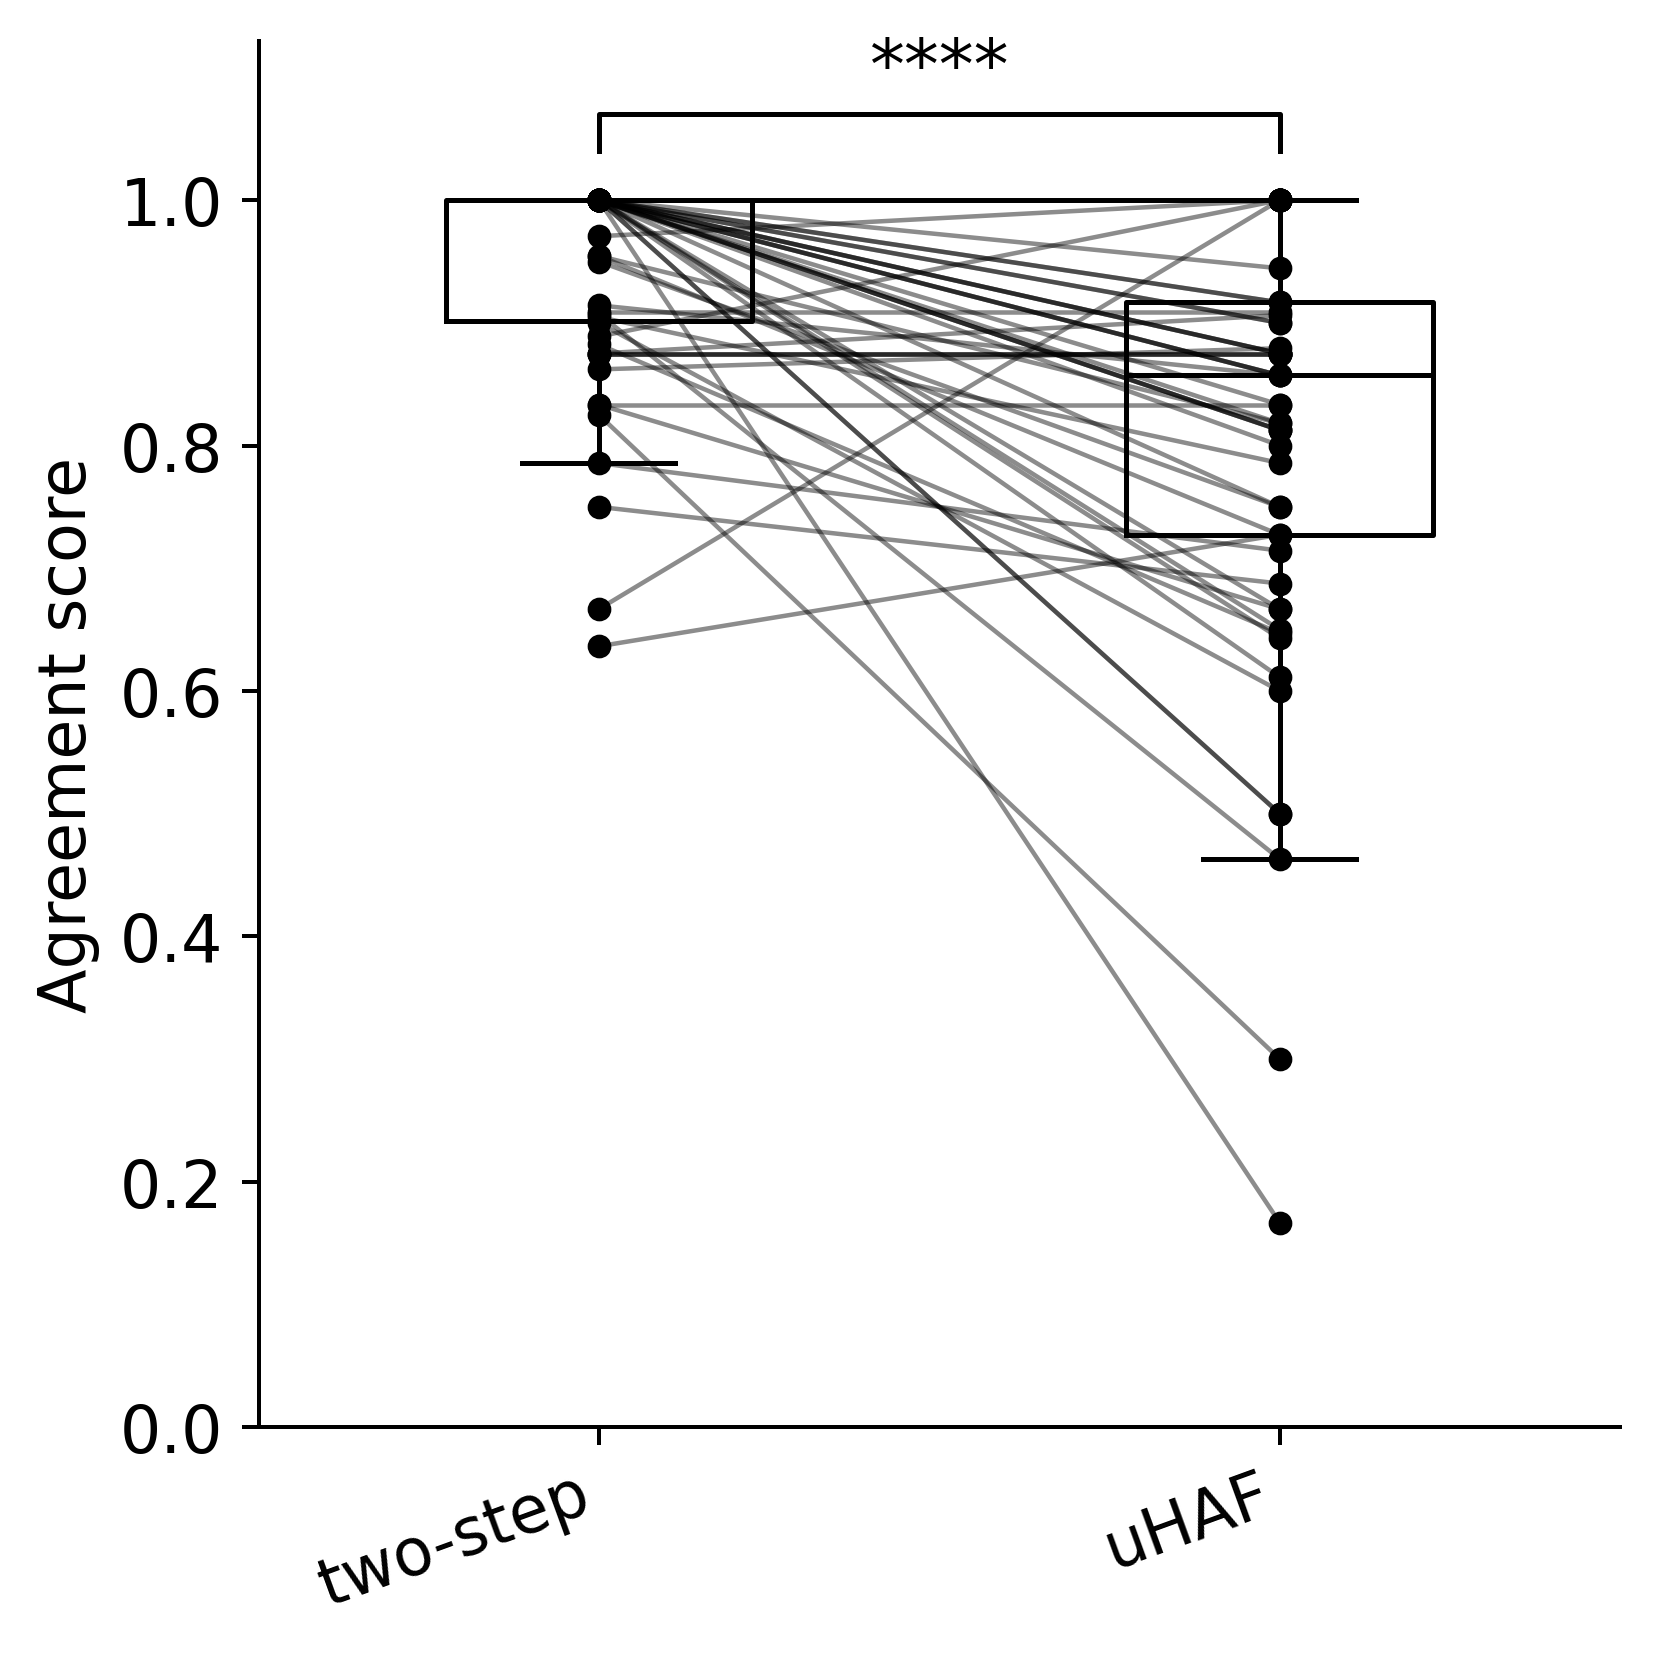

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# -------------------------------
# Helper: score per (tissue, dataset_norm)
# -------------------------------
def score_per_tissue_dataset(df, agreement_col, score_map):
    d = df.copy()
    d["w"] = d[agreement_col].map(score_map)
    out = (
        d.groupby(["tissue", "dataset_norm"])["w"]
         .mean()
         .reset_index(name="score")
    )
    return out

def p_to_star(p):
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 5e-2: return "*"
    return "ns"

# -------------------------------
# Inputs assumed to exist:
#   merged_tab with columns:
#     - tissue
#     - dataset_norm
#     - label for complex strategy
#     - label for uhaf CLname
# -------------------------------
score_map = {'fully match': 1.0, 'partial mismatch': 0.50, 'fully mismatch': 0.0}

# -------------------------------
# Build paired scores (ONE paired point per tissue+dataset_norm)
# -------------------------------
tw_td = score_per_tissue_dataset(merged_tab, "label for complex strategy", score_map)
on_td = score_per_tissue_dataset(merged_tab, "label for uhaf CLname", score_map)

paired = tw_td.merge(
    on_td, on=["tissue", "dataset_norm"], how="inner", suffixes=("_tw", "_on")
).dropna(subset=["score_tw", "score_on"])

# unique key per pair (for plotting lines)
paired["pair_key"] = paired["tissue"].astype(str) + " | " + paired["dataset_norm"].astype(str)

print("Number of paired tissue|dataset points:", paired.shape[0])

# -------------------------------
# Paired Wilcoxon signed-rank test (paired by tissue|dataset)
# -------------------------------
x = paired["score_tw"].to_numpy()
y = paired["score_on"].to_numpy()

stat, p = wilcoxon(x, y, zero_method="zsplit", alternative="two-sided")
star = p_to_star(p)
print(f"Wilcoxon signed-rank: statistic={stat:.4g}, p={p:.3g} -> {star}")

# -------------------------------
# Plot: colorless paired boxplot + connecting lines + significance star
# -------------------------------
fig, ax = plt.subplots(figsize=(5, 5), dpi=360)

data = [x, y]
positions = [1, 2]

bp = ax.boxplot(
    data,
    positions=positions,
    widths=0.45,
    patch_artist=False,   # no filled boxes
    showfliers=False
)

# ensure box/whisker lines are black
for element in ["boxes", "whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1)

# paired points + connecting lines (one line per tissue|dataset)
x1, x2 = positions
for _, r in paired.iterrows():
    ax.plot([x1, x2], [r["score_tw"], r["score_on"]],
            color="black", linewidth=0.9, alpha=0.45)
    ax.scatter([x1, x2], [r["score_tw"], r["score_on"]],
               color="black", s=14, zorder=3)

ax.set_xticks(positions)
ax.set_xticklabels(["two-step", "uHAF"], rotation=20, ha="right")
ax.set_ylabel("Agreement score")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# significance bracket + star
ymax = max(np.max(x), np.max(y))
h = 0.03
pad = 0.04
y_bracket = ymax + pad

ax.plot([x1, x1, x2, x2],
        [y_bracket, y_bracket + h, y_bracket + h, y_bracket],
        color="black", linewidth=1)

ax.text((x1 + x2) / 2, y_bracket + h + 0.01, star,
        ha="center", va="bottom", color="black", fontsize=14)

ax.set_ylim(0, max(1.02, y_bracket + h + 0.06))

plt.tight_layout()
plt.show()


/tmp/ipykernel_4137376/795844010.py:77: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g['pct'] * g['w']).sum() / 100)
/tmp/ipykernel_4137376/795844010.py:77: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g['pct'] * g['w']).sum() / 100)


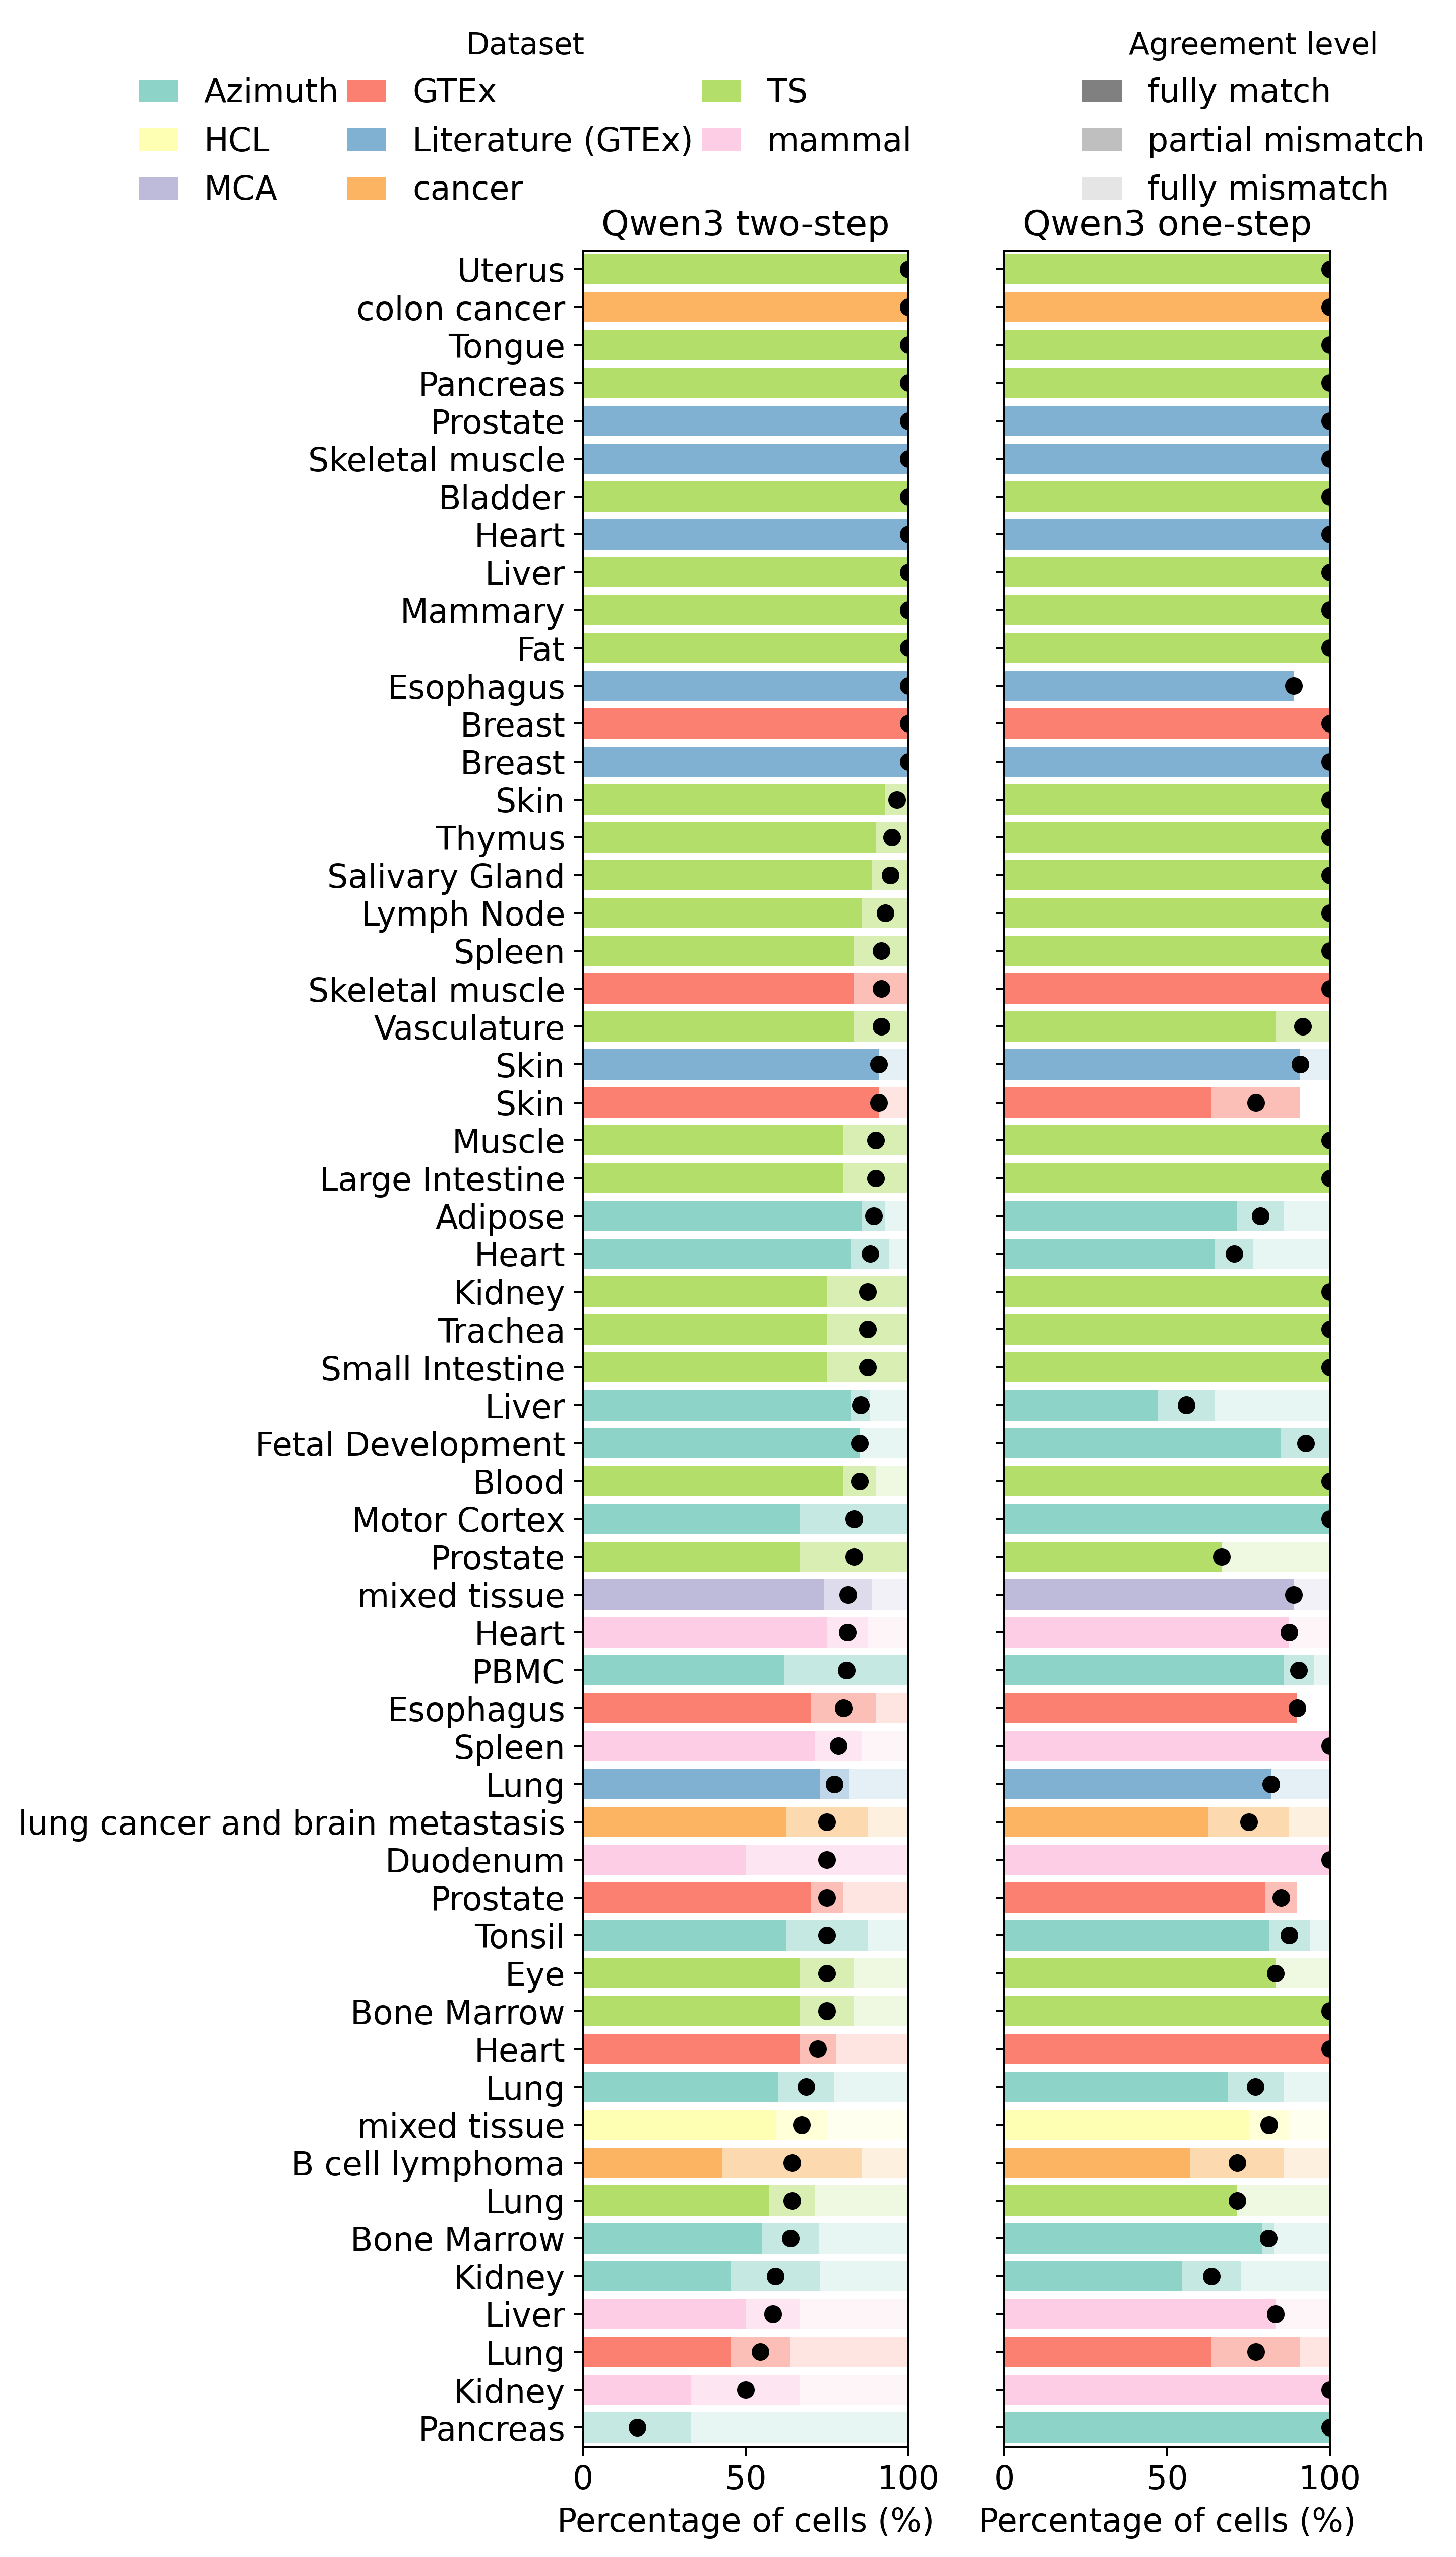

In [5]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

# ---------------------------------------------------------------------
# Load
# ---------------------------------------------------------------------
merged_tab = pd.read_excel("benchmarking_labeled.xlsx").copy()

# ---------------------------------------------------------------------
# Matplotlib style (same as yours)
# ---------------------------------------------------------------------
mpl.rcParams.update({
    'font.size'            : 20,
    'axes.titlesize'       : 14,
    'axes.labelsize'       : 13,
    'xtick.labelsize'      : 13,
    'ytick.labelsize'      : 13,
    'legend.fontsize'      : 13,
    'legend.title_fontsize': 12
})

alpha_map = {'fully match': 1.0, 'partial mismatch': 0.50, 'fully mismatch': 0.20}
score_map = {'fully match': 1.0, 'partial mismatch': 0.50, 'fully mismatch': 0.0}

# ---------------------------------------------------------------------
# Special case HCL/MCA
# ---------------------------------------------------------------------
mask_hcl_mca = merged_tab['dataset'].isin(['HCL', 'MCA'])
merged_tab.loc[mask_hcl_mca, 'tissue'] = 'mixed tissue'

# ---------------------------------------------------------------------
# Normalize dataset names
# ---------------------------------------------------------------------
def normalize_dataset(ds):
    if ds == 'literature':
        return 'Literature (GTEx)'
    if ds in ['BCL', 'coloncancer', 'lungcancer']:
        return 'cancer'
    return ds

merged_tab['dataset_norm'] = merged_tab['dataset'].map(normalize_dataset)

# ---------------------------------------------------------------------
# Colors by normalized dataset
# ---------------------------------------------------------------------
dataset_list = merged_tab['dataset_norm'].unique()
cmap = plt.get_cmap('Set3')
colors = [cmap(i) for i in range(cmap.N) if i != 8]  # skip grey-ish
dataset_colors = {ds: colors[i % len(colors)] for i, ds in enumerate(dataset_list)}

# ---------------------------------------------------------------------
# Pivot/score helper
# ---------------------------------------------------------------------
def make_pivot(df, agreement_col):
    df = df.copy()
    df['tissue_ds'] = df['tissue'] + ' | ' + df['dataset_norm']

    tmp = (
        df.groupby(['tissue_ds', agreement_col])
          .size()
          .reset_index(name='n')
          .rename(columns={agreement_col: 'agreement'})
    )
    tmp['pct'] = tmp['n'] / tmp.groupby('tissue_ds')['n'].transform('sum') * 100

    pivot = (
        tmp.pivot(index='tissue_ds', columns='agreement', values='pct')
           .fillna(0)
    )

    score = (
        tmp.assign(w=tmp['agreement'].map(score_map))
           .groupby('tissue_ds')
           .apply(lambda g: (g['pct'] * g['w']).sum() / 100)
    )

    dataset_per_row = df.groupby('tissue_ds')['dataset_norm'].first()
    tissue_label_per_row = df.groupby('tissue_ds')['tissue'].first()

    return pivot, score, dataset_per_row, tissue_label_per_row

# ---------------------------------------------------------------------
# Build pivots for GPT (title+abstract)
# ---------------------------------------------------------------------
tw_pivot, tw_score, row_ds, row_tissue = make_pivot(
    merged_tab, 'label for qwen_twostep'
)
on_pivot, on_score, _, _ = make_pivot(
    merged_tab, 'label for qwen_onestep'
)

# Sort rows by two-step score (ascending), like your reference
sorted_rows = tw_score.sort_values(ascending=True).index
tw_pivot  = tw_pivot.loc[sorted_rows]
on_pivot  = on_pivot.loc[sorted_rows]
tw_score  = tw_score.loc[sorted_rows]
on_score  = on_score.loc[sorted_rows]
row_ds    = row_ds.loc[sorted_rows]
row_tissue= row_tissue.loc[sorted_rows]

# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------
fig, axes = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(8, 14), dpi=360)

def stacked_alpha_barh(ax, pivot, scores, row_ds_map, row_tissue_map):
    agreements = ['fully match', 'partial mismatch', 'fully mismatch']
    y_pos      = np.arange(len(pivot))
    cum_left   = np.zeros(len(pivot))

    for ag in agreements:
        widths = pivot[ag].values if ag in pivot.columns else np.zeros(len(pivot))
        for i, (w, row_key) in enumerate(zip(widths, pivot.index)):
            if w == 0:
                continue
            ds      = row_ds_map[row_key]
            base_c  = dataset_colors[ds]
            color   = list(base_c)
            color[3]= alpha_map[ag]
            ax.barh(i, w, left=cum_left[i], height=0.8, color=color, edgecolor='none')
        cum_left += widths

    ax.scatter(scores * 100, y_pos, marker='o', color='black', zorder=5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([row_tissue_map[k] for k in pivot.index])
    ax.set_xlim(0, 100)
    ax.set_ylim(len(pivot) - 0.5, -0.5)
    ax.invert_yaxis()
    ax.set_xlabel('Percentage of cells (%)')

stacked_alpha_barh(axes[0], tw_pivot, tw_score, row_ds, row_tissue)
axes[0].set_title('Qwen3 two-step')

stacked_alpha_barh(axes[1], on_pivot, on_score, row_ds, row_tissue)
axes[1].set_title('Qwen3 one-step')
axes[1].set_ylabel('')

# Legends
ds_handles = [Patch(facecolor=dataset_colors[ds], label=ds) for ds in dataset_list]
fig.legend(handles=ds_handles, title='Dataset', loc='upper left',
           bbox_to_anchor=(0.1, 1.02), ncol=3, frameon=False,
           handlelength=1.2, columnspacing=0.25)

grey = (0.5, 0.5, 0.5)
ag_order = ['fully match', 'partial mismatch', 'fully mismatch']
ag_handles = [Patch(facecolor=(*grey, alpha_map[ag]), label=ag) for ag in ag_order]
fig.legend(handles=ag_handles, title='Agreement level', loc='upper left',
           bbox_to_anchor=(0.75, 1.02), ncol=1, frameon=False,
           handlelength=1.2, columnspacing=0.25)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [4]:
merged_tab

,dataset,tissue,manual annotation,manual CLname,GPT-4 corrected annotation(simple),GPT-4 corrected annotation(complex),label for simple strategy,label for complex strategy,qwen_onestep,qwen_twostep,...,label for qwen_twostep,uhaf annotation,label for uhaf,uhaf CLname,label for uhaf CLname,one-step with title and abstract,two-step with title and abstract,label for one-step with title and abstract,label for two-step with title and abstract,dataset_norm
0,Azimuth,PBMC,Intermediate B cell,transitional stage B cell,B-2 B cell,transitional stage B cell,partial mismatch,fully match,germinal center B cell,transitional stage B cell,...,fully match,B cell,partial mismatch,B cell,partial mismatch,monocytoid B cell,transitional stage B cell,partial mismatch,fully match,Azimuth
1,Azimuth,PBMC,Memory B cell,memory B cell,memory B cell,memory B cell,fully match,fully match,memory B cell,memory B cell,...,fully match,Memory B cell,fully match,memory B cell,fully match,memory B cell,memory B cell,fully match,fully match,Azimuth
2,Azimuth,PBMC,Naive B cell,naive B cell,naive B cell,naive B cell,fully match,fully match,naive B cell,naive B cell,...,fully match,Naive B cell,fully match,naive B cell,fully match,naive B cell,naive B cell,fully match,fully match,Azimuth
3,Azimuth,PBMC,Plasmablast,plasmablast,plasmablast,plasmablast,fully match,fully match,plasmablast,plasmablast,...,fully match,Plasma B cell,partial mismatch,plasma cell,partial mismatch,plasmablast,plasmablast,fully match,fully match,Azimuth
4,Azimuth,PBMC,CD4+ Cytotoxic T,"CD4-positive, alpha-beta cytotoxic T cell","CD4-positive, alpha-beta cytotoxic T cell","CD4-positive, alpha-beta cytotoxic T cell",fully match,fully match,"CD4-positive, alpha-beta cytotoxic T cell",cytotoxic T cell,...,fully match,Effector CD4 T cell,partial mismatch,"effector memory CD4-positive, alpha-beta T cel...",partial mismatch,"CD4-positive, alpha-beta cytotoxic T cell","CD4-positive, alpha-beta cytotoxic T cell",fully match,fully match,Azimuth
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
551,mammal,Spleen,Neurons,neuron,neuron,neuron,fully match,fully match,neuron,neuron,...,fully match,Neuron,fully match,neuron,fully match,neuron of the forebrain,neuron,partial mismatch,fully match,mammal
552,mammal,Spleen,T cells,T cell,T cell,T cell,fully match,fully match,T cell,T cell,...,fully match,T cell,fully match,T cell,fully match,T cell,T cell,fully match,fully match,mammal
553,mammal,Spleen,Dendrocytes,dendritic cell,nephrocyte,dendritic cell,partial mismatch,fully match,dendritic cell,club cell,...,fully mismatch,Dendritic cell,fully match,dendritic cell,fully match,"dendritic cell, human",microglial cell,partial mismatch,fully mismatch,mammal
554,mammal,Duodenum,Endothelial cells,endothelial cell,endothelial cell,endothelial cell,fully match,fully match,endothelial cell,cardiac endothelial cell,...,fully match,NaN,fully mismatch,NaN,NaN,pulmonary artery endothelial cell,endothelial cell,partial mismatch,fully match,mammal


In [31]:
import pandas as pd
import numpy as np

merged_tab = pd.read_excel("Figure_2c_data_merged_all_methods.xlsx")

# ✅ Block B style: exclude rows where manual CLname is NA
filtered = merged_tab.dropna(subset=["manual CLname"]).copy()

method_to_labelcol = {
    "GPT one-step"      : "label for simple strategy",
    "GPT two-step"      : "label for complex strategy",
    "Qwen one-step"     : "label for qwen_onestep",
    "Qwen two-step"     : "label for qwen_twostep",
    "UHAF (annotation)" : "label for uhaf",
    "UHAF (CLname)"     : "label for uhaf CLname",
    "GPT+TA one-step"   : "label for one-step with title and abstract",
    "GPT+TA two-step"   : "label for two-step with title and abstract",
}

def rate_fully_match(s):
    s = s.dropna()
    return np.nan if len(s) == 0 else (s == "fully match").mean()

def rate_partial(s):
    s = s.dropna()
    return np.nan if len(s) == 0 else (s == "partial mismatch").mean()

def rate_fully_mismatch(s):
    s = s.dropna()
    return np.nan if len(s) == 0 else (s == "fully mismatch").mean()

# -------------------------
# 1) Per (tissue, dataset) rates for each method
# -------------------------
per_td_all = []
for method, col in method_to_labelcol.items():
    tmp = (
        filtered
        .groupby(["tissue", "dataset"],dropna=False)[col]
        .agg(
            n=lambda x: x.notna().sum(),
            accuracy=rate_fully_match,
            partial_rate=rate_partial,
            error_rate=rate_fully_mismatch
        )
        .reset_index()
    )
    tmp.insert(0, "method", method)
    per_td_all.append(tmp)

per_td_df = pd.concat(per_td_all, ignore_index=True)

# -------------------------
# 2) Block B overall: average across (tissue, dataset) combinations (unweighted)
# -------------------------
overall_blockB = (
    per_td_df
    .groupby("method")
    .agg(
        n_groups=("accuracy", lambda s: s.notna().sum()),
        avg_accuracy=("accuracy", "mean"),
        avg_partial_rate=("partial_rate", "mean"),
        avg_error_rate=("error_rate", "mean")
    )
    .reset_index()
    .sort_values("avg_accuracy", ascending=False)
)

print("=== Block B overall (mean across tissue-dataset combos) ===")
print(overall_blockB.to_string(index=False))

# Save outputs
overall_blockB.to_csv("Figure_2c_overall_blockB_unweighted.csv", index=False)
per_td_df.to_csv("Figure_2c_per_tissue_dataset_all_methods_blockB.csv", index=False)


=== Block B overall (mean across tissue-dataset combos) ===
           method  n_groups  avg_accuracy  avg_partial_rate  avg_error_rate
     GPT two-step        58      0.899340          0.091974        0.008686
  GPT+TA two-step        58      0.898036          0.039191        0.062772
    Qwen one-step        58      0.894166          0.045165        0.060668
     GPT one-step        58      0.884378          0.098320        0.017303
    Qwen two-step        58      0.819553          0.086329        0.094119
    UHAF (CLname)        47      0.709626          0.215679        0.074695
  GPT+TA one-step        58      0.664327          0.189850        0.145823
UHAF (annotation)        58      0.404834          0.358074        0.237093


In [2]:
import pandas as pd
import numpy as np

merged_tab = pd.read_excel("benchmarking_labeled.xlsx")

# ✅ Block B style: exclude rows where manual CLname is NA
filtered = merged_tab.dropna(subset=["manual CLname"]).copy()

method_to_labelcol = {
    "GPT one-step"      : "label for simple strategy",
    "GPT two-step"      : "label for complex strategy",
    "Qwen one-step"     : "label for qwen_onestep",
    "Qwen two-step"     : "label for qwen_twostep",
    "UHAF (annotation)" : "label for uhaf",
    "UHAF (CLname)"     : "label for uhaf CLname",
    "GPT+TA one-step"   : "label for one-step with title and abstract",
    "GPT+TA two-step"   : "label for two-step with title and abstract",
}

def rate_fully_match(s):
    s = s.dropna()
    return np.nan if len(s) == 0 else (s == "fully match").mean()

def rate_partial(s):
    s = s.dropna()
    return np.nan if len(s) == 0 else (s == "partial mismatch").mean()

def rate_fully_mismatch(s):
    s = s.dropna()
    return np.nan if len(s) == 0 else (s == "fully mismatch").mean()

# -------------------------
# 1) Per (tissue, dataset) rates for each method
# -------------------------
per_td_all = []
for method, col in method_to_labelcol.items():
    tmp = (
        filtered
        .groupby(["tissue", "dataset"])[col]
        .agg(
            n=lambda x: x.notna().sum(),
            accuracy=rate_fully_match,
            partial_rate=rate_partial,
            error_rate=rate_fully_mismatch
        )
        .reset_index()
    )
    tmp.insert(0, "method", method)
    per_td_all.append(tmp)

per_td_df = pd.concat(per_td_all, ignore_index=True)

# -------------------------
# 2) Block B overall: MEDIAN across (tissue, dataset) combinations (unweighted)
# -------------------------
overall_blockB = (
    per_td_df
    .groupby("method")
    .agg(
        n_groups=("accuracy", lambda s: s.notna().sum()),
        median_accuracy=("accuracy", "median"),
        median_partial_rate=("partial_rate", "median"),
        median_error_rate=("error_rate", "median"),
        # optional: keep mean too (remove if you don't want it)
        mean_accuracy=("accuracy", "mean"),
        mean_partial_rate=("partial_rate", "mean"),
        mean_error_rate=("error_rate", "mean"),
    )
    .reset_index()
    .sort_values("median_accuracy", ascending=False)
)

print("=== Block B overall (median across tissue-dataset combos) ===")
print(overall_blockB.to_string(index=False))

# Save outputs
overall_blockB.to_csv("Figure_2c_overall_blockB_unweighted_median.csv", index=False)
per_td_df.to_csv("Figure_2c_per_tissue_dataset_all_methods_blockB.csv", index=False)


=== Block B overall (median across tissue-dataset combos) ===
           method  n_groups  median_accuracy  median_partial_rate  median_error_rate  mean_accuracy  mean_partial_rate  mean_error_rate
     GPT one-step        56         1.000000             0.000000            0.00000       0.888371           0.094267         0.017363
     GPT two-step        56         1.000000             0.000000            0.00000       0.906864           0.085256         0.007880
  GPT+TA two-step        56         1.000000             0.000000            0.00000       0.934825           0.026982         0.038193
    Qwen one-step        56         1.000000             0.000000            0.00000       0.891377           0.036537         0.072086
    Qwen two-step        56         0.800000             0.000000            0.12500       0.769376           0.070681         0.159943
  GPT+TA one-step        56         0.750000             0.146429            0.00000       0.694092           0.197642    

In [3]:
import pandas as pd
import numpy as np

merged_tab = pd.read_excel("benchmarking_labeled.xlsx")

# ✅ Block B style: exclude rows where manual CLname is NA
filtered = merged_tab.dropna(subset=["manual CLname"]).copy()

method_to_labelcol = {
    "GPT one-step"      : "label for simple strategy",
    "GPT two-step"      : "label for complex strategy",
    "Qwen one-step"     : "label for qwen_onestep",
    "Qwen two-step"     : "label for qwen_twostep",
    "UHAF (annotation)" : "label for uhaf",
    "UHAF (CLname)"     : "label for uhaf CLname",
    "GPT+TA one-step"   : "label for one-step with title and abstract",
    "GPT+TA two-step"   : "label for two-step with title and abstract",
}

def rate_fully_match(s):
    s = s.dropna()
    return np.nan if len(s) == 0 else (s == "fully match").mean()

# ✅ changed: "partial_rate" = proportion of (fully match OR partial mismatch)
def rate_partial(s):
    s = s.dropna()
    if len(s) == 0:
        return np.nan
    return s.isin(["fully match", "partial mismatch"]).mean()

def rate_fully_mismatch(s):
    s = s.dropna()
    return np.nan if len(s) == 0 else (s == "fully mismatch").mean()

# -------------------------
# 1) Per (tissue, dataset) rates for each method
# -------------------------
per_td_all = []
for method, col in method_to_labelcol.items():
    tmp = (
        filtered
        .groupby(["tissue", "dataset"])[col]
        .agg(
            n=lambda x: x.notna().sum(),
            accuracy=rate_fully_match,
            partial_rate=rate_partial,
            error_rate=rate_fully_mismatch
        )
        .reset_index()
    )
    tmp.insert(0, "method", method)
    per_td_all.append(tmp)

per_td_df = pd.concat(per_td_all, ignore_index=True)

# -------------------------
# 2) Block B overall: MEDIAN across (tissue, dataset) combinations (unweighted)
# -------------------------
overall_blockB = (
    per_td_df
    .groupby("method")
    .agg(
        n_groups=("accuracy", lambda s: s.notna().sum()),
        median_accuracy=("accuracy", "median"),
        median_partial_rate=("partial_rate", "median"),
        median_error_rate=("error_rate", "median"),
        # optional: keep mean too (remove if you don't want it)
        mean_accuracy=("accuracy", "mean"),
        mean_partial_rate=("partial_rate", "mean"),
        mean_error_rate=("error_rate", "mean"),
    )
    .reset_index()
    .sort_values("median_accuracy", ascending=False)
)

print("=== Block B overall (median across tissue-dataset combos) ===")
print(overall_blockB.to_string(index=False))

=== Block B overall (median across tissue-dataset combos) ===
           method  n_groups  median_accuracy  median_partial_rate  median_error_rate  mean_accuracy  mean_partial_rate  mean_error_rate
     GPT one-step        56         1.000000                1.000            0.00000       0.888371           0.982637         0.017363
     GPT two-step        56         1.000000                1.000            0.00000       0.906864           0.992120         0.007880
  GPT+TA two-step        56         1.000000                1.000            0.00000       0.934825           0.961807         0.038193
    Qwen one-step        56         1.000000                1.000            0.00000       0.891377           0.927914         0.072086
    Qwen two-step        56         0.800000                0.875            0.12500       0.769376           0.840057         0.159943
  GPT+TA one-step        56         0.750000                1.000            0.00000       0.694092           0.891734    

In [6]:
# -------------------------
# 2) Cumulative thresholds: >0.9, >0.8, >0.7, <=0.7 (per method)
# -------------------------
thr_labels = [">=0.9", ">=0.8", ">=0.7", "<0.7"]
thr_values = [0.9, 0.8, 0.7]

valid = per_td_df.dropna(subset=["accuracy"]).copy()

# denominator per method = number of non-NaN accuracy tissue-dataset groups
denom = (
    valid.groupby("method")
         .size()
         .rename("total_groups")
         .reset_index()
)

rows = []
for method, d in valid.groupby("method"):
    total = len(d)
    rows.append({"method": method, "bucket": ">=0.9", "pct_groups": 100.0 * (d["accuracy"] >= 0.9).mean()})
    rows.append({"method": method, "bucket": ">=0.8", "pct_groups": 100.0 * (d["accuracy"] >= 0.8).mean()})
    rows.append({"method": method, "bucket": ">=0.7", "pct_groups": 100.0 * (d["accuracy"] >= 0.7).mean()})
    rows.append({"method": method, "bucket": "<0.7", "pct_groups": 100.0 * (d["accuracy"] < 0.7).mean()})

bucket_pct = pd.DataFrame(rows)

# wide table (methods as rows, buckets as columns)
bucket_wide = (
    bucket_pct.pivot(index="method", columns="bucket", values="pct_groups")
              .reindex(columns=thr_labels)
              .fillna(0.0)
              .reset_index()
)

print("=== % of tissue-dataset groups by threshold bucket (per method) ===")
print(bucket_wide.to_string(index=False))


=== % of tissue-dataset groups by threshold bucket (per method) ===
           method     >=0.9     >=0.8     >=0.7      <0.7
     GPT one-step 60.714286 73.214286 87.500000 12.500000
     GPT two-step 69.642857 78.571429 91.071429  8.928571
  GPT+TA one-step 25.000000 37.500000 60.714286 39.285714
  GPT+TA two-step 73.214286 87.500000 98.214286  1.785714
    Qwen one-step 60.714286 78.571429 83.928571 16.071429
    Qwen two-step 32.142857 53.571429 67.857143 32.142857
    UHAF (CLname) 21.428571 46.428571 69.642857 30.357143
UHAF (annotation)  1.785714  3.571429 17.857143 82.142857


In [7]:
per_td_df

,method,tissue,dataset,n,accuracy,partial_rate,error_rate
0,GPT one-step,Adipose,Azimuth,14,0.785714,0.928571,0.071429
1,GPT one-step,B cell lymphoma,BCL,7,0.285714,0.714286,0.285714
2,GPT one-step,Bladder,TS,4,1.000000,1.000000,0.000000
3,GPT one-step,Blood,TS,10,1.000000,1.000000,0.000000
4,GPT one-step,Bone Marrow,Azimuth,29,0.793103,1.000000,0.000000
...,...,...,...,...,...,...,...
443,GPT+TA two-step,Trachea,TS,4,1.000000,1.000000,0.000000
444,GPT+TA two-step,Uterus,TS,4,1.000000,1.000000,0.000000
445,GPT+TA two-step,Vasculature,TS,6,1.000000,1.000000,0.000000
446,GPT+TA two-step,colon cancer,coloncancer,5,1.000000,1.000000,0.000000


In [8]:
thr_labels = [">=0.9", ">=0.8", ">=0.7", "<0.7"]
thr_values = [0.9, 0.8, 0.7]

valid = per_td_df.dropna(subset=["partial_rate"]).copy()

# denominator per method = number of non-NaN accuracy tissue-dataset groups
denom = (
    valid.groupby("method")
         .size()
         .rename("total_groups")
         .reset_index()
)

rows = []
for method, d in valid.groupby("method"):
    total = len(d)
    rows.append({"method": method, "bucket": ">=0.9", "pct_groups": 100.0 * (d["partial_rate"] >= 0.9).mean()})
    rows.append({"method": method, "bucket": ">=0.8", "pct_groups": 100.0 * (d["partial_rate"] >= 0.8).mean()})
    rows.append({"method": method, "bucket": ">=0.7", "pct_groups": 100.0 * (d["partial_rate"] >= 0.7).mean()})
    rows.append({"method": method, "bucket": "<0.7", "pct_groups": 100.0 * (d["partial_rate"] < 0.7).mean()})

bucket_pct = pd.DataFrame(rows)

# wide table (methods as rows, buckets as columns)
bucket_wide = (
    bucket_pct.pivot(index="method", columns="bucket", values="pct_groups")
              .reindex(columns=thr_labels)
              .fillna(0.0)
              .reset_index()
)

print("=== % of tissue-dataset groups by threshold bucket (per method) ===")
print(bucket_wide.to_string(index=False))

=== % of tissue-dataset groups by threshold bucket (per method) ===
           method     >=0.9      >=0.8      >=0.7      <0.7
     GPT one-step 94.642857  96.428571 100.000000  0.000000
     GPT two-step 96.428571 100.000000 100.000000  0.000000
  GPT+TA one-step 71.428571  80.357143  85.714286 14.285714
  GPT+TA two-step 83.928571  96.428571  98.214286  1.785714
    Qwen one-step 66.071429  89.285714  96.428571  3.571429
    Qwen two-step 42.857143  66.071429  80.357143 19.642857
    UHAF (CLname) 21.428571  46.428571  69.642857 30.357143
UHAF (annotation) 57.142857  80.357143  82.142857 17.857143
